## <center>🔍 Exploratory Data Analysis (EDA)</center>

![Нефть и газ](https://avatars.mds.yandex.net/i?id=f0c6e485cc98b2d1ee4633e48d076c80_l-5315578-images-thumbs&n=13.jpg)

---

### 🎯 Цель аналитического блока

Цель данного аналитического блока — **глубокое исследование структуры, качества и экономического смысла данных по добыче нефти и газа в США**, а также формирование **обоснованных предпосылок для дальнейшего прогнозирования временных рядов**.

EDA в рамках этого проекта выполняет **не вспомогательную**, а **ключевую методологическую роль**, поскольку исходные данные:
- являются **регуляторной отчётностью**, а не прямыми измерениями добычи;
- содержат большое количество **нулевых и корректировочных записей**;
- обладают сложной **иерархической и пространственной структурой**.

Без тщательного предварительного анализа использование стандартных моделей временных рядов может привести к **методологически неверным выводам**.

---

### 📌 Бизнес- и исследовательские вопросы

В рамках EDA рассматриваются следующие ключевые вопросы:

1. **Какова реальная структура данных OGOR?**  
   - Какие операции формируют фактическую добычу?
   - Какова доля корректировок и нулевых отчётов?

2. **Насколько пригодны исходные данные для моделирования временных рядов?**  
   - Требуется ли агрегация?
   - Какие временные и структурные искажения присутствуют?

3. **Существуют ли принципиальные различия между нефтью и газом?**  
   - По бизнес-логике учёта;
   - По географии добычи;
   - По временной динамике.

4. **Присутствуют ли структурные сдвиги и режимные изменения?**  
   - Можно ли рассматривать весь период как однородный?
   - Какой временной сегмент релевантен для прогнозирования?

---

### 🗂 Описание данных

В анализе используется датасет **OGOR (Oil and Gas Operations Report)**, содержащий агрегированную отчётность операторов по добыче нефти и газа на федеральных землях США.

| Поле | Описание |
|------|----------|
| **Production Date** | Дата добычи (месяц / год) |
| **Land Class** | Тип собственности: Federal / Native American / Mixed Exploratory |
| **Land Category** | Onshore (суша) / Offshore (море) |
| **State / County / FIPS** | Геолокация (может отсутствовать для offshore) |
| **Offshore Region** | Регион морской добычи |
| **Commodity** | Тип ресурса: нефть (bbl) / газ (Mcf) |
| **Disposition Code / Description** | Тип операции с продукцией |
| **Volume** | Отчётный объём (может быть положительным, нулевым или отрицательным) |

---

### 🧠 Методологические допущения

В ходе анализа используются следующие допущения:

- **Отрицательные значения объёма** интерпретируются как корректировки ранее задекларированных данных.
- **Нулевые значения** отражают технологические, отчётные или регуляторные операции без товарного выхода.
- **Фактическая добыча** формируется совокупностью положительных операций и требует агрегации по времени.

---

### 🧭 Структура аналитического блока

EDA организован следующим образом:

1. Первичный анализ качества данных и распределений.
2. Экономическая интерпретация операций OGOR.
3. Анализ пространственного распределения добычи.
4. Агрегация данных и анализ временной динамики.
5. Исследование сезонности и трендов.
6. Проверка взаимосвязей между нефтью и газом.
7. Поиск структурных сдвигов.
8. Формирование решений для этапа моделирования.

---

### 🔗 Связь с последующими этапами проекта

Результаты данного EDA напрямую используются для:
- выбора периода моделирования;
- определения целевых временных рядов;
- обоснования применения моделей **Exponential Smoothing**, **Prophet** и **VAR**;
- проектирования production-пайплайна прогнозирования.

Таким образом, данный аналитический блок является **фундаментом всей последующей модели** и определяет корректность интерпретации итоговых прогнозов.


# <center> 🔄 Загрузка библиотек <center>

In [1]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px      
from plotly.subplots import make_subplots

sns.set_style("whitegrid")
pastel_palette = sns.color_palette("pastel")

from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.seasonal import seasonal_decompose

import ruptures as rpt

from scipy import stats

import warnings        
warnings.filterwarnings('ignore')

In [2]:
def check_stationarity(series, commodity, alpha=0.05):
    """
    Проверка стационарности временного ряда с помощью статистических тестов.
    
    Параметры:
        series (pd.Series): Временной ряд
        alpha (float): Уровень значимости
        method (str): 'adf', 'kpss' или 'both'
    
    Возвращает:
        dict: Результаты тестов
    """
    
    # Тест Дики-Фуллера (ADF)
    adf_result = adfuller(series, autolag='AIC')
    
    # Тест KPSS
    try:
        kpss_result = kpss(series, regression='ct', nlags='auto') 
    except:
        kpss_result = kpss(series, regression='c', nlags='auto')

    # Интерпретация результатов
    print(f"Результаты проверки стационарности {commodity}:\n")
    print(f"Уровень значимости: {alpha}")
    print(f"Тест Дики-Фуллера (ADF): pvalue= {adf_result[1]:.4f}")
    print(f"Тест KPSS: p-value = {kpss_result[1]:.4f}")

    # Совместная интерпретация
    adf_stationary = adf_result[1] < alpha
    kpss_stationary = kpss_result[1] > alpha
    
    if adf_stationary and kpss_stationary:
        print(f'Вывод: Ряд стационарен {commodity}\n')
    elif not adf_stationary and not kpss_stationary:
        print(f'Вывод: Ряд нестационарен (тренд) {commodity}\n')
    elif adf_stationary and not kpss_stationary:
        print(f'Вывод: Ряд стационарен вокруг детерминированного тренда {commodity}\n')
    else:
        print(f'Вывод: Результаты противоречивы {commodity}\n')

# <center> 🔄 Загрузка данных <center>

In [3]:
df = pd.read_csv('../data/raw/OGORB.csv',
                parse_dates=['Production Date'],
                thousands=","
)

print("✅ Датасет загружен!")

print("\nПервые пять строк:")
display(df.head())

print("\nОбщая информация:")
print("="*50)
df.info()

print("\nОписательная статистика:")
display(df.describe(include='all'))

print("\n📊 Основные характеристики")
print(f"• Объем данных: {df.shape[0]:,} записей, {df.shape[1]} признаков")
print(f"• Покрытие: данные за {df['Production Date'].iloc[0]} - {df['Production Date'].iloc[-1]}")
print(f"• География: {df['State'].nunique()} штатов, {df['County'].nunique()} округов")
print(f"• Уникальных операций: {df['Disposition Description'].nunique()}")

print("\n🔍 Анализ пропущенных значений:")
print("="*50)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})

display(missing_df[missing_df['Missing Count'] > 0])

print(f"\n🔍 Анализ дубликатов (все столбцы одинаковые)")
print("-" * 50)
    
print(f"• Количество полных дубликатов: {len(df) - len(df.drop_duplicates())}")
print(f"• Уникальных записей: {len(df.drop_duplicates())}")

✅ Датасет загружен!

Первые пять строк:


,Production Date,Land Class,Land Category,State,County,FIPS Code,Offshore Region,Commodity,Disposition Code,Disposition Description,Volume
0,2015-01-01,Federal,Offshore,NaN,NaN,NaN,Offshore Alaska,Gas (Mcf),1,Sales-Royalty Due-MEASURED,0
1,2015-01-01,Federal,Offshore,NaN,NaN,NaN,Offshore Gulf,Gas (Mcf),1,Sales-Royalty Due-MEASURED,14508756
2,2015-01-01,Federal,Offshore,NaN,NaN,NaN,Offshore Pacific,Gas (Mcf),1,Sales-Royalty Due-MEASURED,1207520
3,2015-01-01,Federal,Offshore,NaN,NaN,NaN,Offshore Gulf,Gas (Mcf),4,Sales-Royalty Due-Not Measured,487324
4,2015-01-01,Federal,Offshore,NaN,NaN,NaN,Offshore Pacific,Gas (Mcf),4,Sales-Royalty Due-Not Measured,114808



Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470830 entries, 0 to 470829
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Production Date          470830 non-null  datetime64[ns]
 1   Land Class               470830 non-null  object        
 2   Land Category            470830 non-null  object        
 3   State                    454200 non-null  object        
 4   County                   454200 non-null  object        
 5   FIPS Code                454200 non-null  float64       
 6   Offshore Region          10196 non-null   object        
 7   Commodity                470830 non-null  object        
 8   Disposition Code         470830 non-null  int64         
 9   Disposition Description  470830 non-null  object        
 10  Volume                   470830 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memor

,Production Date,Land Class,Land Category,State,County,FIPS Code,Offshore Region,Commodity,Disposition Code,Disposition Description,Volume
count,470830,470830,470830,454200,454200,454200.000000,10196,470830,470830.000000,470830,4.708300e+05
unique,NaN,3,2,27,318,NaN,3,2,NaN,35,NaN
top,NaN,Federal,Onshore,WY,Eddy,NaN,Offshore Gulf,Gas (Mcf),NaN,Sales-Royalty Due-MEASURED,NaN
freq,NaN,434168,460634,63936,9526,NaN,5672,235415,NaN,63024,NaN
mean,2020-02-07 07:46:47.744621568,NaN,NaN,NaN,NaN,33246.875359,NaN,NaN,18.445779,NaN,1.325708e+05
min,2015-01-01 00:00:00,NaN,NaN,NaN,NaN,1003.000000,NaN,NaN,1.000000,NaN,-2.587792e+07
25%,2017-07-01 00:00:00,NaN,NaN,NaN,NaN,22027.000000,NaN,NaN,10.000000,NaN,0.000000e+00
50%,2020-02-01 00:00:00,NaN,NaN,NaN,NaN,35045.000000,NaN,NaN,17.000000,NaN,0.000000e+00
75%,2022-10-01 00:00:00,NaN,NaN,NaN,NaN,48225.000000,NaN,NaN,25.000000,NaN,1.600000e+02
max,2025-05-01 00:00:00,NaN,NaN,NaN,NaN,56045.000000,NaN,NaN,69.000000,NaN,8.362804e+07



📊 Основные характеристики
• Объем данных: 470,830 записей, 11 признаков
• Покрытие: данные за 2015-01-01 00:00:00 - 2025-05-01 00:00:00
• География: 27 штатов, 318 округов
• Уникальных операций: 35

🔍 Анализ пропущенных значений:


,Missing Count,Missing Percentage
State,16630,3.532060
County,16630,3.532060
FIPS Code,16630,3.532060
Offshore Region,460634,97.834463



🔍 Анализ дубликатов (все столбцы одинаковые)
--------------------------------------------------
• Количество полных дубликатов: 0
• Уникальных записей: 470830


# Предобработка

In [4]:
# Обработка пропусков в географических признаках
# 1️⃣ Offshore Region:
# Если поле отсутствует → значит Onshore (суша)
df['Offshore Region'] = df['Offshore Region'].fillna('Onshore')

# 2️⃣ State / County :
# Если значения отсутствуют → Offshore (шельф)
df['State'] = df['State'].fillna('Offshore')
df['County'] = df['County'].fillna('Offshore')

print("\nПосле заполнения пропусков:")
display(df[['Offshore Region', 'State', 'County']].isna().sum())

# Делаем данные читаемыми
state_map = {
    'Offshore': 'Offshore (Federal Waters)',
    'AK': 'Alaska', 'AL': 'Alabama', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana',
    'MI': 'Michigan', 'MS': 'Mississippi', 'MT': 'Montana', 'ND': 'North Dakota',
    'NM': 'New Mexico', 'NY': 'New York', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'PA': 'Pennsylvania', 'SD': 'South Dakota', 'TX': 'Texas', 'UT': 'Utah',
    'VA': 'Virginia', 'WV': 'West Virginia', 'WY': 'Wyoming', 'IL': 'Illinois',
    'NE': 'Nebraska', 'NV': 'Nevada', 'ID': 'Idaho'
}

state_map_inv = {v: k for k, v in state_map.items()}

df['State'] = df['State'].replace(state_map)

df.to_csv("../data/processed/OGORB_clean.csv", index=False)

# Анализ будем проводить раздельно по типу сырья 
oil_df = df[df['Commodity'] == 'Oil (bbl)'].reset_index(drop=True)
gas_df = df[df['Commodity'] == 'Gas (Mcf)'].reset_index(drop=True)

# Признак FIPS Code дублирует комбинацию State–County, признак Disposition Code кодирует Disposition Description.
oil_df.drop(columns=['Commodity', 'FIPS Code', 'Disposition Code'], axis=1, inplace=True)
gas_df.drop(columns=['Commodity', 'FIPS Code', 'Disposition Code'], axis=1, inplace=True)


После заполнения пропусков:


Offshore Region    0
State              0
County             0
dtype: int64

## 🧮 Анализ распределения неагрегированных объёмов


===  🎯 Анализ неагрегированных (сырых) объемов ===

Общая статистика Volume (Oil_df):
count    2.354150e+05
mean     4.767830e+04
std      1.057651e+06
min     -2.698390e+05
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.086666e+07
Name: Volume, dtype: float64

Общая статистика Volume (Gas_df):
count    2.354150e+05
mean     2.174633e+05
std      2.374750e+06
min     -2.587792e+07
25%      0.000000e+00
50%      2.000000e+00
75%      1.874000e+03
max      8.362804e+07
Name: Volume, dtype: float64



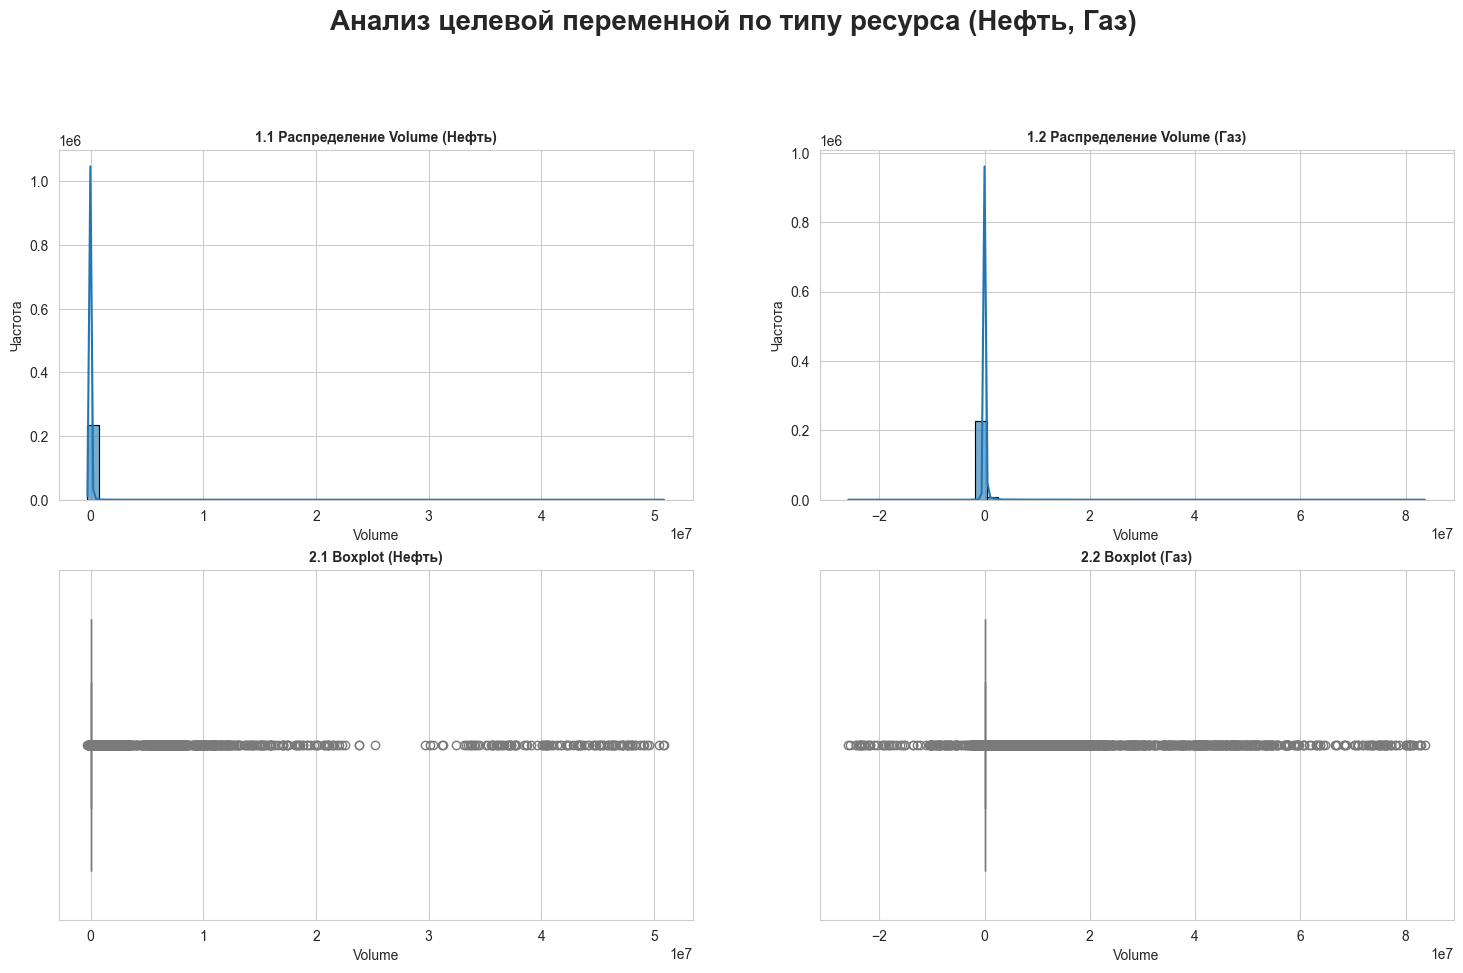

In [5]:
print("\n===  🎯 Анализ неагрегированных (сырых) объемов ===\n")

print(f"Общая статистика Volume (Oil_df):")
print(f"{oil_df['Volume'].describe()}\n")

print(50*"=")

print(f"Общая статистика Volume (Gas_df):")
print(f"{gas_df['Volume'].describe()}\n")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Анализ целевой переменной по типу ресурса (Нефть, Газ)', fontsize=20, y=1.02, fontweight='bold')

sns.histplot(oil_df, x='Volume', bins=50, palette='pastel', alpha=0.6, edgecolor='black', kde=True, ax=axes[0][0])
axes[0][0].set_title('1.1 Распределение Volume (Нефть)', fontsize=10, fontweight='bold')
axes[0][0].set_xlabel('Volume')
axes[0][0].set_ylabel('Частота')

sns.histplot(gas_df, x='Volume', bins=50, palette='pastel', alpha=0.6, edgecolor='black', kde=True, ax=axes[0][1])
axes[0][1].set_title('1.2 Распределение Volume (Газ)', fontsize=10, fontweight='bold')
axes[0][1].set_xlabel('Volume')
axes[0][1].set_ylabel('Частота')

sns.boxplot(data=oil_df, x='Volume', palette='pastel', ax=axes[1][0], gap=.1)
axes[1][0].set_title('2.1 Boxplot (Нефть)', fontsize=10, fontweight='bold')
axes[1][0].set_xlabel('Volume')

sns.boxplot(data=gas_df, x='Volume', palette='pastel', ax=axes[1][1], gap=.1)
axes[1][1].set_title('2.2 Boxplot (Газ)', fontsize=10, fontweight='bold')
axes[1][1].set_xlabel('Volume');

**Основные выводы по распределению неагрегированных объёмов**:

- Стандартное отклонение (std) огромно и сопоставимо или даже превышает среднее значение, что подтверждает высокий разброс данных.

- Максимальные значения (max) на несколько порядков превышают 75-й перцентиль (75%) и среднее значение.

    - Нефть (Oil_df) 🛢️: max = 50.9 млн bbl против 75% = 0 bbl.

    - Газ (Gas_df) 🔥: max = 83.6 млн Mcf против 75% = 1,874 Mcf.

Вывод: Анализ объемов, лучше проводить не по "сырым", а по агрегированным данным (суммарный объём за месяц). Это сгладит временной ряд и сделает его менее шумным.

## 🎯 Исследование классов целевой переменной (объемов)


===  🎯 Исследование классов целевой переменной (объемов) ===

Volume (Oil_df):
Доля положительных значений: 17.47%
Доля отрицательных значений: 2.24%
Доля нулевых значений: 80.29%
Volume (Gas_df):
Доля положительных значений: 51.02%
Доля отрицательных значений: 3.30%
Доля нулевых значений: 45.68%


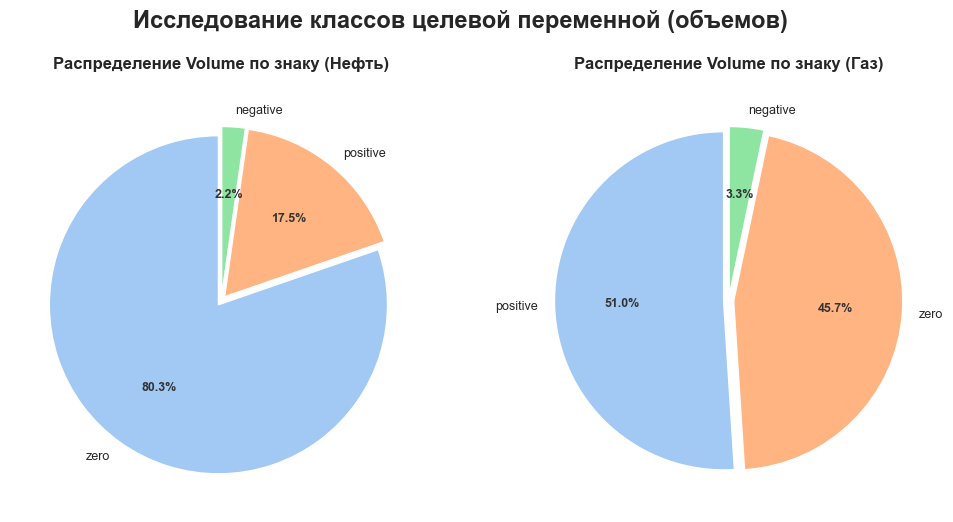

In [6]:
print("\n===  🎯 Исследование классов целевой переменной (объемов) ===\n")

print(f"Volume (Oil_df):")
print(f"Доля положительных значений: {(oil_df['Volume'] > 0).mean():.2%}")
print(f"Доля отрицательных значений: {(oil_df['Volume'] < 0).mean():.2%}")
print(f"Доля нулевых значений: {(oil_df['Volume'] == 0).mean():.2%}")

print(50*"=")

print(f"Volume (Gas_df):")
print(f"Доля положительных значений: {(gas_df['Volume'] > 0).mean():.2%}")
print(f"Доля отрицательных значений: {(gas_df['Volume'] < 0).mean():.2%}")
print(f"Доля нулевых значений: {(gas_df['Volume'] == 0).mean():.2%}")

# --- Классификация по знаку ---
for df in [oil_df, gas_df]:
    df.loc[df['Volume'] > 0, 'target_class'] = 'positive'
    df.loc[df['Volume'] == 0, 'target_class'] = 'zero'
    df.loc[df['Volume'] < 0, 'target_class'] = 'negative'

oil_counts = oil_df['target_class'].value_counts(normalize=True)
gas_counts = gas_df['target_class'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Исследование классов целевой переменной (объемов)', fontsize=17, fontweight='bold')

# График 1.1: Распределение объемов по знаку (Нефть)
wedges_oil, texts_oil, autotexts_oil = axes[0].pie(
    oil_counts,
    labels=oil_counts.index,
    autopct='%.1f%%',
    colors=pastel_palette,  
    startangle=90,
    shadow=False,  
    explode=[0.03] * len(oil_counts), 
    textprops={'fontsize': 9}
)

# Отображение процентов
for autotext in autotexts_oil:
    autotext.set_color('#333333') 
    autotext.set_fontweight('bold')

axes[0].set_title('Распределение Volume по знаку (Нефть)', 
                 fontsize=12, fontweight='bold', pad=15)

# График 1.1: Распределение объемов по знаку (Газ)
wedges_gas, texts_gas, autotexts_gas = axes[1].pie(
    gas_counts,
    labels=gas_counts.index,
    autopct='%.1f%%',
    colors=pastel_palette,  
    startangle=90,
    shadow=False,
    explode=[0.03] * len(gas_counts),
    textprops={'fontsize': 9}
)

# Отображение процентов
for autotext in autotexts_gas:
    autotext.set_color('#333333') 
    autotext.set_fontweight('bold')

axes[1].set_title('Распределение Volume по знаку (Газ)', 
                 fontsize=12, fontweight='bold', pad=15);

## Общая логика категоризации
- **Positive (+)** — операции, увеличивающие учтённую добычу или реализацию
- **Zero (0)** — операции без движения товарной продукции или утилизация  
- **Negative (–)** — корректировки, возвраты или закупки сторонней продукции

---

> 🔍 Согласно официальной документации ONRR (источник датасета), отрицательные объёмы часто отражают корректировки предыдущих отчётов — например, если оператор изначально завысил объём, а потом внёс исправление в следующем месяце. Т.е. отрицательное значение = «откат» предыдущего положительного. 

На основе документа Minerals Production Reporter Handbook можно выделить несколько ключевых причин, по которым нулевые отчеты по добыче (особенно для нефтяных скважин) могут встречаться чаще, чем для газовых: 

  **1. Разные режимы работы скважин**

    - Нефтяные скважины часто работают в циклическом или прерывистом режиме (например, из-за истощения пласта, необходимости проведения ремонтных работ, использования методов увеличения нефтеотдачи).

    - Газовые скважины, как правило, работают более стабильно и непрерывно, так как газ легче добывать и транспортировать.

  **2. Технические простои**

    - Нефтяные скважины чаще требуют технического обслуживания (например, очистка от парафина, ремонт насосного оборудования), что приводит к простоям.

  **3. Экономические причины**

    - Если цена на нефть низкая, операторы могут приостанавливать добычу на некоторых скважинах, чтобы дождаться более выгодных условий.

    - Газовые скважины часто связаны контрактами на поставку, поэтому их остановка экономически менее выгодна.

  **4. Особенности отчетности**

    - Даже если скважина не работает, оператор обязан подавать OGOR-A ежемесячно до тех пор, пока скважина не будет окончательно ликвидирована.

**Основные выводы по распределению неагрегированных объёмов**:

---

Большинство записей имеют нулевой объем, а также присутствуют отрицательные значения:

- Нефть (Oil_df) 🛢️: 80.29% нулевых значений. 2.24% отрицательных значений. Только 17.47% записей имеют положительный объём.

- Газ (Gas_df) 🔥:  45.68% нулевых значений. 3.30% отрицательных значений. Положительных объемов чуть больше половины (51.02%).

Вывод: Необходимо  провести раздельный анализ (положительных, отрицательных, нулевых объемов) по распределению для выявления характерных паттернов.

# Раздельный анализ (положительных, отрицательных, нулевых объемов) по распределению для выявления характерных паттернов

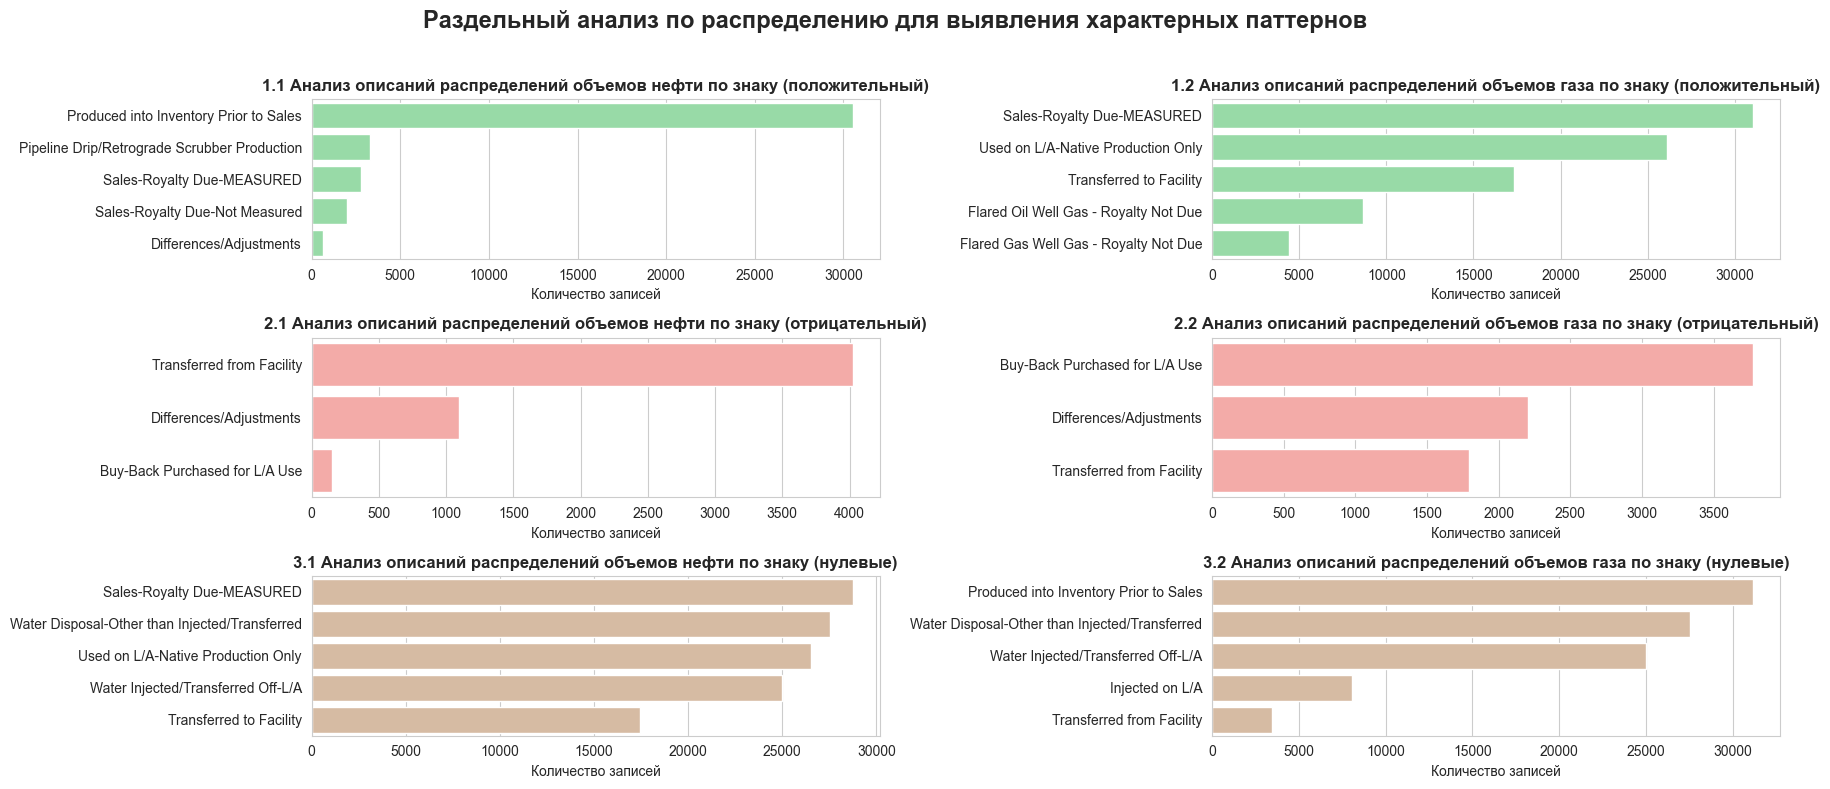

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(18, 8))
fig.suptitle('Раздельный анализ по распределению для выявления характерных паттернов', fontsize=17, fontweight='bold')

oil_group = oil_df.groupby(['target_class', 'Disposition Description'])['Volume'].count()
gas_group = gas_df.groupby(['target_class', 'Disposition Description'])['Volume'].count()

oil_pos = oil_group.loc['positive'].nlargest(5)
oil_neg = oil_group.loc['negative'].nlargest(5)
oil_zero = oil_group.loc['zero'].nlargest(5)

gas_pos = gas_group.loc['positive'].nlargest(5)
gas_neg = gas_group.loc['negative'].nlargest(5)
gas_zero = gas_group.loc['zero'].nlargest(5)

# --- Positive ---
sns.barplot(x=oil_pos.values, y=oil_pos.index.to_list(), color=sns.color_palette("pastel")[2], ax=axes[0,0])
axes[0,0].set_title("1.1 Анализ описаний распределений объемов нефти по знаку (положительный)", fontweight='bold')
axes[0,0].set_xlabel('Количество записей')

sns.barplot(x=gas_pos.values, y=gas_pos.index.to_list(), color=sns.color_palette("pastel")[2], ax=axes[0,1])
axes[0,1].set_title("1.2 Анализ описаний распределений объемов газа по знаку (положительный)", fontweight='bold')
axes[0,1].set_xlabel('Количество записей')

# --- Negative ---
sns.barplot(x=oil_neg.values, y=oil_neg.index.to_list(), color=sns.color_palette("pastel")[3], ax=axes[1,0])
axes[1,0].set_title("2.1 Анализ описаний распределений объемов нефти по знаку (отрицательный)", fontweight='bold')
axes[1,0].set_xlabel('Количество записей')

sns.barplot(x=gas_neg.values, y=gas_neg.index.to_list(), color=sns.color_palette("pastel")[3], ax=axes[1,1])
axes[1,1].set_title("2.2 Анализ описаний распределений объемов газа по знаку (отрицательный)", fontweight='bold')
axes[1,1].set_xlabel('Количество записей')

# --- Zero ---
sns.barplot(x=oil_zero.values, y=oil_zero.index.to_list(), color=sns.color_palette("pastel")[5], ax=axes[2,0])
axes[2,0].set_title("3.1 Анализ описаний распределений объемов нефти по знаку (нулевые)", fontweight='bold')
axes[2,0].set_xlabel('Количество записей')

sns.barplot(x=gas_zero.values, y=gas_zero.index.to_list(), color=sns.color_palette("pastel")[5], ax=axes[2,1])
axes[2,1].set_title("3.2 Анализ описаний распределений объемов газа по знаку (нулевые)", fontweight='bold')
axes[2,1].set_xlabel('Количество записей')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Отчёт по распределению операций OGOR по типам объёмов

---

## 1. Положительные объёмы (Positive)
**Формируют основу для начисления роялти**

### 1.1 Нефтяные операции 🛢️
| Код | Название операции | Когда применяется |
|-----|-------------------|-------------------|
| **10** | **Produced into Inventory Prior to Sales** | Используется, когда нефть/конденсат/CO₂ поступает в резервуар для хранения, и продажа будет происходить позже |

### 1.2 Газовые операции 🔥
| Код | Название операции | Когда применяется |
|-----|-------------------| -------------------|
| **01** | **Sales-Royalty Due-MEASURED** | При прямой продаже с месторождения, подлежащие роялти, измеренные в утверждённой точке определения роялти  |
| **20** | **Used on L/A-Native Production Only** | Только для газа собственной добычи, используемого на месторождении с предварительного разрешения регулятора |
| **11** | **Transferred to Facility** | Передача на объект обработки (осушка, очистка) перед определением роялти|

---

## 2. Отрицательные объёмы (Negative)
**Корректировочные операции (<3% от общего объёма)**

| Код | Название операции | Когда применяется |
|-----|-------------------|-------------------|
| **42** | **Differences/Adjustments** | Корректировочная запись для технических расхождений, потерь и поправок между учтёнными и фактическими объёмами |
| **13** | **Transferred from Facility** | Для возврата или аллокации продукции с объекта на месторождение |
| **25** | **Buy-Back Purchased for L/A Use** | Отрицательная запись всего объёма нефти/газа, закупленного на стороне для использования на месторождении |

**Ключевые особенности:**
- Технический характер операций
- Не формируют базу для роялти
- Исправляют ранее учтённые данные

---

## 3. Нулевые объёмы (Zero)
**Операции без товарного выхода или утилизация**

### 3.1 Нефтяные нулевые операции 🛢️
| Код | Название операции | Причина нулевого учёта |
|-----|-------------------|------------------------|
| **01** | Sales-Royalty Due-MEASURED | *Нефть не продаётся напрямую* |
| **27** | Water Disposal-Other than Injected/Transferred | *Утилизация воды* |
| **20** | Used on L/A-Native Production Only | *Нефть не используется как топливо* |
| **17** | Water Injected/Transferred Off-L/A | *Вода передана на другие месторождения* |
| **11** | Transferred to Facility | *Нефть обычно не передаётся на обработку* |

### 3.2 Газовые нулевые операции 🔥
| Код | Название операции | Причина нулевого учёта |
|-----|-------------------|------------------------|
| **10** | Produced into Inventory Prior to Sales | *Газ не хранится в резервуарах* |
| **27** | Water Disposal-Other than Injected/Transferred | *Утилизация воды* |
| **17** | Water Injected/Transferred Off-L/A | *Вода передана на другие месторождения* |

**Объяснение логики:**
- Для нефти: операция 01 (продажа) может быть нулевой, если нефть не продаётся, а накапливается
- Для газа: операция 10 (хранение) всегда нулевая, так как газ физически не хранится в танках
- Водные операции всегда нулевые в товарном учёте

---

## Выводы

1. **Positive операции** — ядро отчётности, разделены по продукту:
   - Нефть 🛢️: акцент на хранение перед продажей
   - Газ 🔥: акцент на продажу и использование на месте

2. **Negative операции** — минимальны по объёму, но критичны для точности учёта

3. **Zero операции** — отражают технологические процессы без товарного выхода:
   - Для нефти 🛢️: случаи, когда она не продаётся напрямую
   - Для газа 🔥: операции, которые физически невозможны (хранение в танках)
   - Водные операции всегда нулевые

4. **Регуляторная значимость**:
   - Positive: основа для фискальных расчётов
   - Zero/Negative: прозрачность полного цикла, аудит потерь

---

*Отчёт составлен на основе анализа Minerals Production Reporter Handbook (ONRR Release 2.0, 09/15/2014).*

---

➡️ Таким образом, `Disposition Description` — **главный детерминант типа записи**,  и может использоваться как ведущий признак в классификации.

---

### Предварительные гипотезы для моделирования

1. **Классификация записей:**  `Disposition Description` и `Commodity` способны объяснить принадлежность к определенной категории в общем датасете.
- **Проверка**: Построение модели классификации и проверка важности фичей (feature importance) Файл US Oil & Gas P & D (Classification).

2. **Прогнозирование агрегированных значений месячных объемов:**  Данные агрегированные за месяц менее шумные, сглаживаюстя все корректировки (US Oil & Gas P & D (Modeling)).

# <center> 📈 Ресурсный анализ по общим объемам</center>

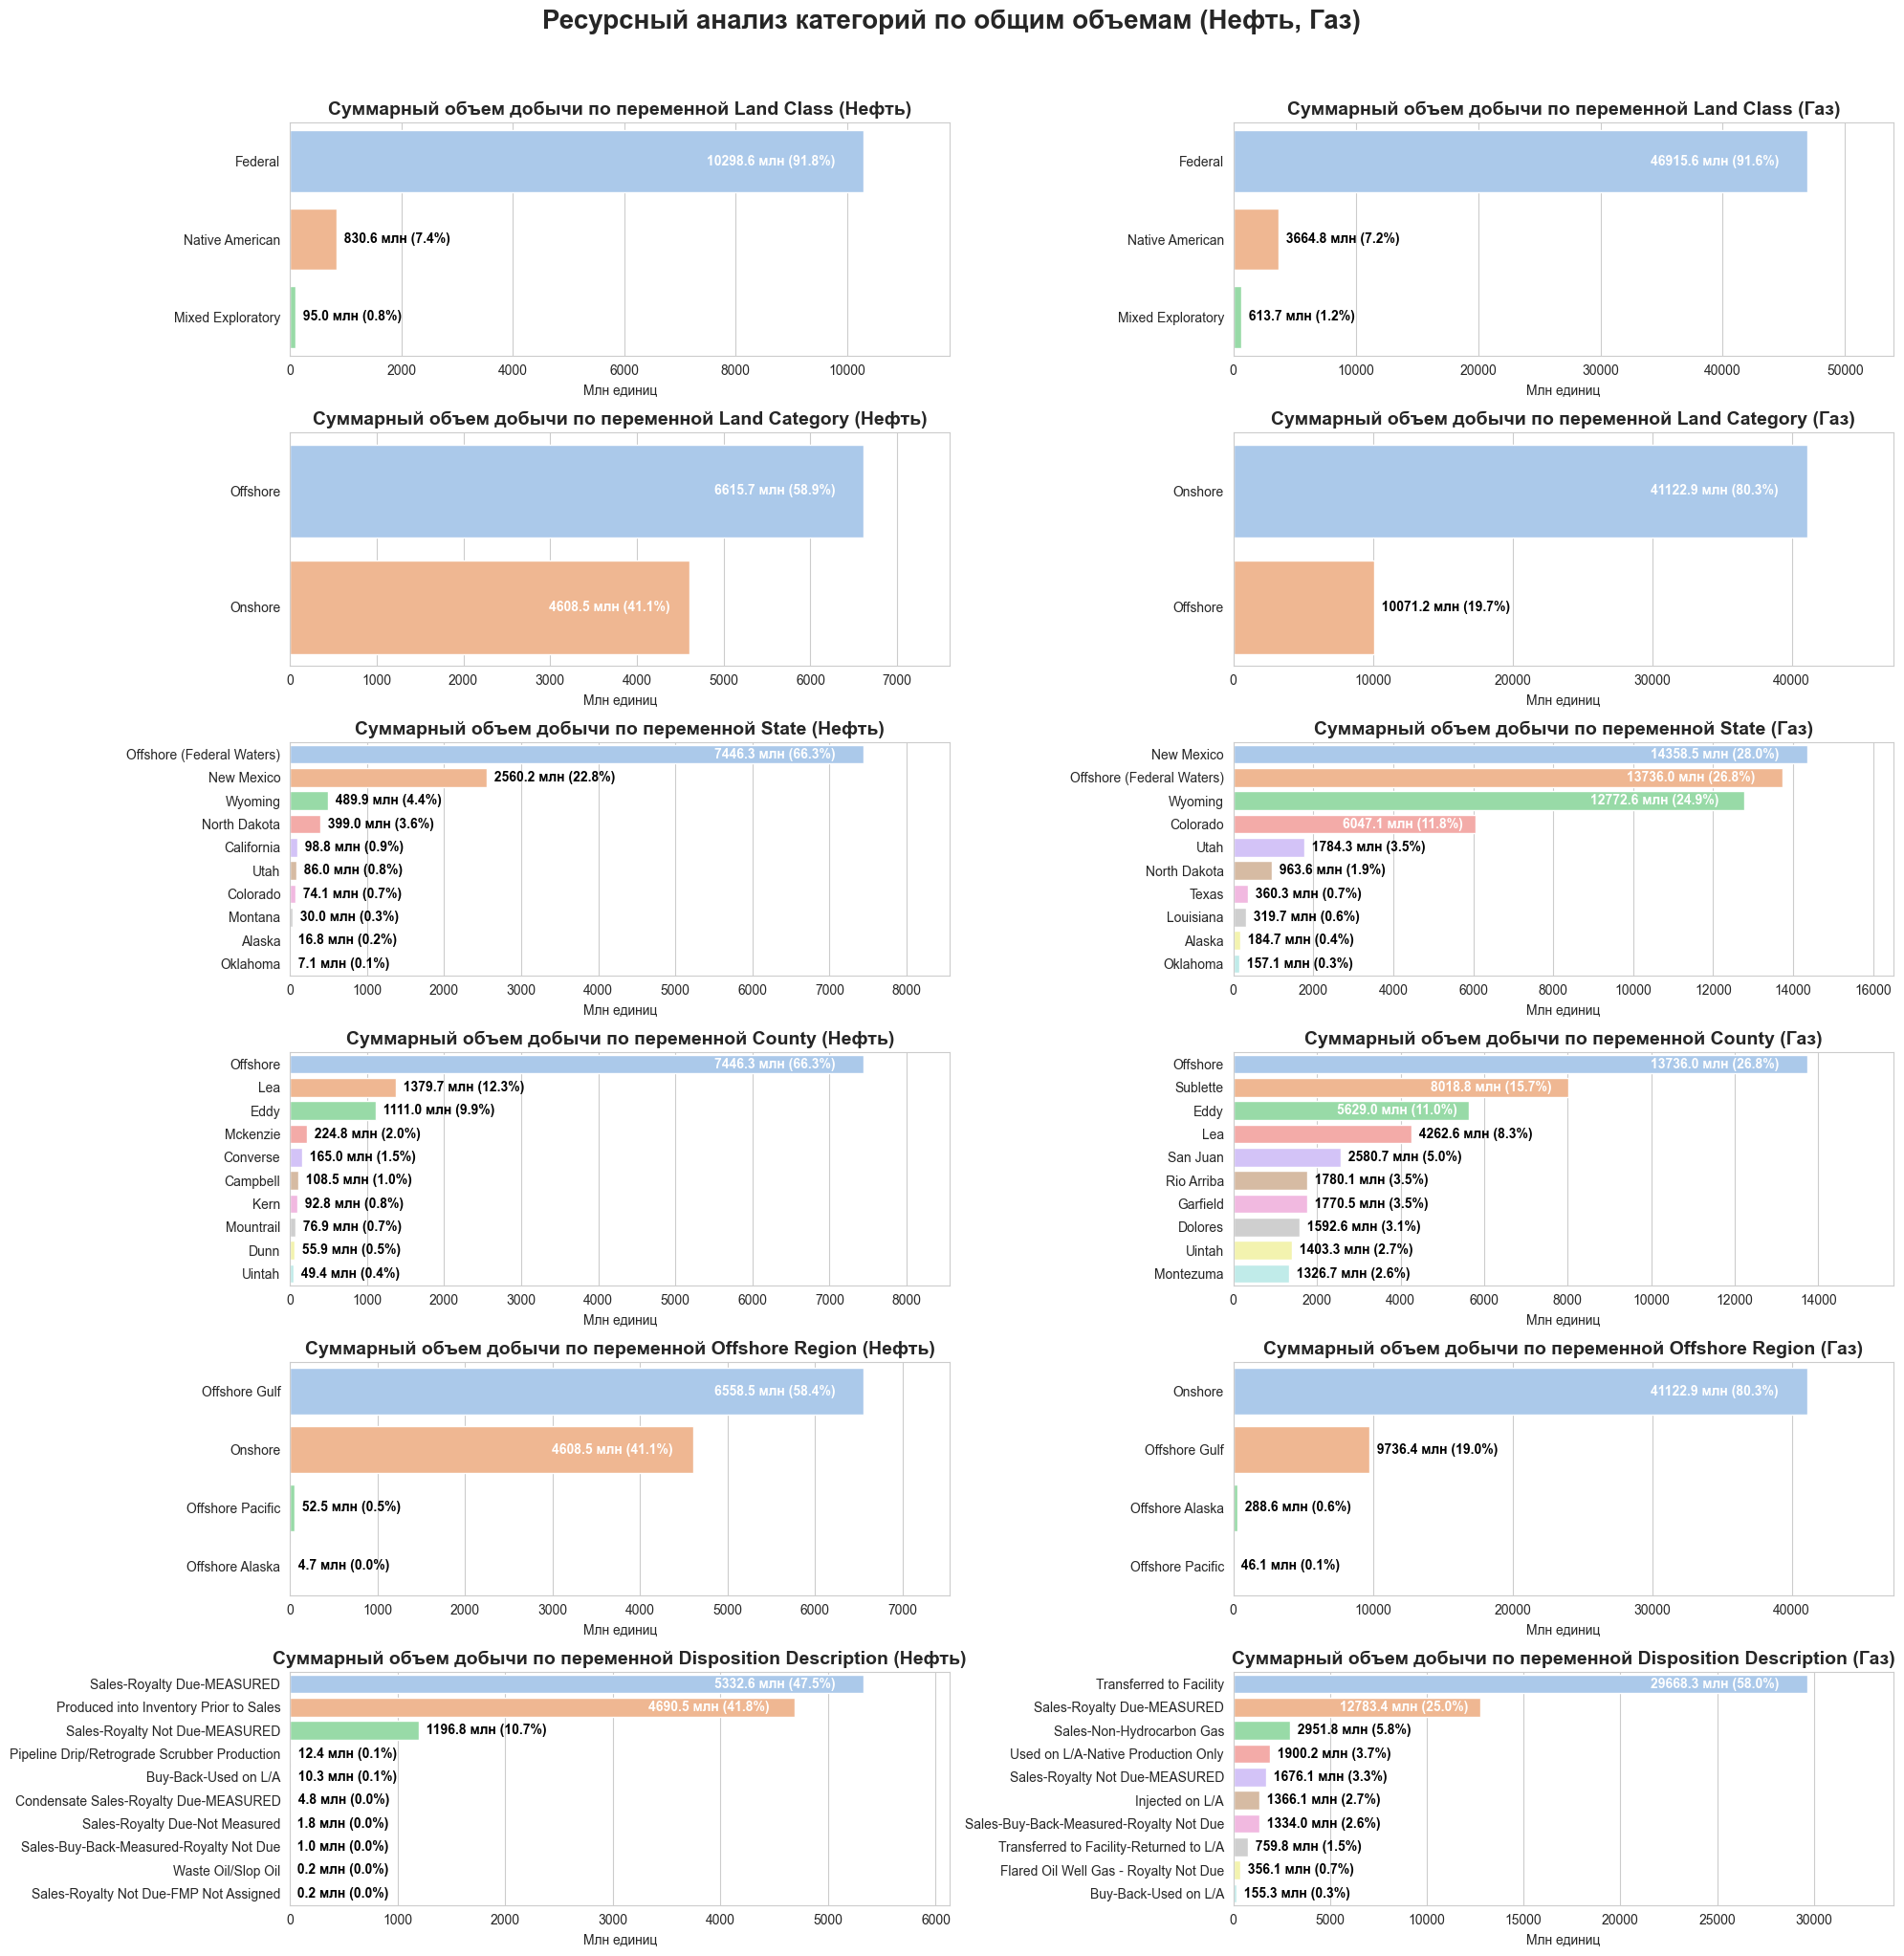

In [8]:
cat_columns = oil_df.select_dtypes('object').columns.to_list()
cat_columns = cat_columns[:-1]

fig, axes = plt.subplots(6, 2, figsize=(20, 20))
fig.suptitle('Ресурсный анализ категорий по общим объемам (Нефть, Газ)', fontsize=20, y=1.02, fontweight='bold')

for i, cat_name in enumerate(cat_columns):

    # Группируем по категории и суммируем объем
    volume_by_category_oil = oil_df.groupby(cat_name)['Volume'].sum() / 1e6  # в миллионах
    volume_by_category_gas = gas_df.groupby(cat_name)['Volume'].sum() / 1e6  # в миллионах
    
    # Берем топ-10 категорий по объему (самые большие)
    volume_by_category_oil = volume_by_category_oil.nlargest(10).sort_values(ascending=False)
    volume_by_category_gas = volume_by_category_gas.nlargest(10).sort_values(ascending=False)
    
    # Общий объем для расчета процентов
    total_volume_oil = oil_df['Volume'].sum() / 1e6  # общий объем в миллионах
    total_volume_gas = gas_df['Volume'].sum() / 1e6  # общий объем в миллионах
    
    # Строим график
    sns.barplot(x=volume_by_category_oil.values, y=range(len(volume_by_category_oil)), 
                orient='h', palette='pastel', ax=axes[i][0])
    
    sns.barplot(x=volume_by_category_gas.values, y=range(len(volume_by_category_gas)), 
                orient='h', palette='pastel', ax=axes[i][1])
    
    # Добавляем подписи с процентами
    max_value_oil = volume_by_category_oil.max()
    max_value_gas = volume_by_category_gas.max()

    for j, (category_name, volume) in enumerate(zip(volume_by_category_oil.index, volume_by_category_oil.values)):

        percentage = (volume / total_volume_oil) * 100  # процент от общего объема
        
        if volume < max_value_oil * 0.4:  
            axes[i][0].text(volume, j, f'  {volume:.1f} млн ({percentage:.1f}%)', 
                        va='center', fontweight='bold', fontsize=10, color='black')
        else: 
            axes[i][0].text(volume * 0.95, j, f'{volume:.1f} млн ({percentage:.1f}%)', 
                        va='center', fontweight='bold', fontsize=10, color='white',
                        ha='right')
            
    for j, (category_name, volume) in enumerate(zip(volume_by_category_gas.index, volume_by_category_gas.values)):

        percentage = (volume / total_volume_gas) * 100  # процент от общего объема
        
        if volume < max_value_gas * 0.4: 
            axes[i][1].text(volume, j, f'  {volume:.1f} млн ({percentage:.1f}%)', 
                        va='center', fontweight='bold', fontsize=10, color='black')
        else: 
            axes[i][1].text(volume * 0.95, j, f'{volume:.1f} млн ({percentage:.1f}%)', 
                        va='center', fontweight='bold', fontsize=10, color='white',
                        ha='right')
    
    axes[i][0].set_title(f'Суммарный объем добычи по переменной {cat_name} (Нефть)', fontsize=14, fontweight='bold')
    axes[i][0].set_xlabel('Млн единиц')
    axes[i][0].set_yticklabels(volume_by_category_oil.index)

    axes[i][1].set_title(f'Суммарный объем добычи по переменной {cat_name} (Газ)', fontsize=14, fontweight='bold')
    axes[i][1].set_xlabel('Млн единиц')
    axes[i][1].set_yticklabels(volume_by_category_gas.index)
    
    x_max_oil = volume_by_category_oil.max() * 1.15
    axes[i][0].set_xlim(0, x_max_oil)

    x_max_gas = volume_by_category_gas.max() * 1.15
    axes[i][1].set_xlim(0, x_max_gas)

plt.tight_layout()
plt.show()

### 1. Суммарный объём добычи по типу земель (Land Class)
- **Нефть 🛢️:** основная часть добычи приходится на **федеральные земли** — 10 298.6 млн (91.8%). Доля **Native American** земель составляет 830.6 млн (7.4%), а **Mixed Exploratory** — 95.0 млн (0.8%).  
- **Газ 🔥:** аналогично, **федеральные земли** формируют 46 915.6 млн (91.6%). **Native American** территории дают 3 664.8 млн (7.2%), **Mixed Exploratory** — 613.7 млн (1.2%).

**Вывод:** Подавляющий объём добычи обоих ресурсов сосредоточен на федеральных землях.

---

### 2. Суммарный объём добычи по категории земель (Land Category)
- **Нефть 🛢️:** 58.9% приходится на **Offshore** добычу (6 615.7 млн), 41.1% — на **Onshore** (4 608.5 млн).  
- **Газ 🔥:** наоборот — **Onshore** доминирует с объёмом 41 122.9 млн (80.3%), тогда как **Offshore** — 10 071.2 млн (19.7%).

**Вывод:** Нефть добывается преимущественно на морском шельфе, а газ — на суше.

---

### 3. Суммарный объём добычи по штатам (State)
- **Нефть 🛢️:** лидирует **Offshore (Federal Waters)** (7 446.3 млн; 66.3%) , далее — **New Mexico** (2 560.2 млн; 22.8%), **Wyoming**, **North Dakota**, **California**.  
- **Газ 🔥:** основные объёмы приходятся на **New Mexico** (14 358.5 млн; 28.%), **Offshore Federal Waters** (13 736. млн; 26.8%) и **Wyoming** (12 772.6 млн; 24.9%).

**Вывод:** В обоих случаях ключевые производственные регионы — **New Mexico** и **Offshore Federal Waters**.

---

### 4. Суммарный объём добычи по округам (County)
- **Нефть 🛢️:** крупнейшие округа — **Lea (12.3%)**, **Eddy (9.9%)**.  
- **Газ 🔥:** ведущие округа — **Sublette (15.7%)**, **Eddy (11.0%)**, **Lea (8.3%)**.

**Вывод:** Нефтяная добыча концентрируется в округах **Lea** и **Eddy**, газовая — в **Sublette** и соседних регионах Нью-Мексико.

---

### 5. Суммарный объём добычи по офшорным регионам (Offshore Region)
- **Нефть 🛢️:** основная доля приходится на **Offshore Gulf** — 6 558.5 млн (58.4%), при незначительных долях **Offshore Pacific** — 52.5 млн (0.5%) и **Offshore Alaska** — 4.7 млн.  
- **Газ 🔥:** **Offshore Gulf** также доминирует — 9 736.4 млн (19.0%), при незначительных долях **Offshore Alaska** (288.6 млн; 0.6%) и **Offshore Pacific** (46.1 млн; 0.1%).

**Вывод:** Шельф Мексиканского залива является основным офшорным источником как нефти, так и газа.

---

### 6. Суммарный объём добычи по типу распределения (Disposition Description)
- **Нефть 🛢️:** почти весь объём (5 332.6 млн; 47.5%) проходит по категории **Sales-Royalty Due-MEASURED**, что указывает на коммерческую реализацию с начислением роялти и по категориии **Produced into inventory Prior to Sales** (4 690.5 млн; 41.8%) что указывает на хранение с полседующей продажей.  
- **Газ 🔥:** Почти весь объём (29 668.3 млн; 58.0%) проходит по категории **Transferred to Facility**, что указывает на что значительная доля сырья отправляется на переработку на предприятия. Категория **Sales-Royalty Due-MEASURED** формирует (12 783.4 млн; 25.0%).

**Вывод:** Анализ распределения добычи по категориям диспозиции чётко демонстрирует различие в фундаментальных бизнес-моделях для нефти и газа:

- Нефть 🛢️ — это в первую очередь готовый к продаже товар. Её путь направлен на максимизацию коммерческой выручки через прямые продажи или стратегическое хранение. Логистика сфокусирована на оптимизации цепочки добыча → (хранение) → продажа.

- Газ 🔥 — это в значительной степени сырьё для переработки. Основной объём направляется на объекты инфраструктуры (ГПЗ), где создаётся добавленная стоимость. Его модель сложнее и зависит от наличия специализированных объектов переработки и контрактных обязательств (добыча → переработка → продажа продуктов).

---

### 7. Итоговые наблюдения
1. Основной объём добычи нефти и газа сосредоточен **на федеральных землях**.  
2. **Нефтяная добыча** преобладает **в офшорных зонах**, в то время как **газовая — на суше (onshore)**.  
3. **Ключевые регионы:** штат **New Mexico**, а также **Offshore Federal Waters** (особенно Gulf).  
4. Анализ распределения добычи по категориям диспозиции чётко демонстрирует различие в фундаментальных бизнес-моделях для нефти и газа.  
5. Пространственная концентрация ресурсов чётко выражена: несколько регионов и категорий обеспечивают подавляющую часть общих объёмов.

# Динамика производства общих объемов

In [9]:
month_dict = {
    'January': 'Январь',
    'February': 'Февраль', 
    'March': 'Март',
    'April': 'Апрель',
    'May': 'Май',
    'June': 'Июнь',
    'July': 'Июль',
    'August': 'Август',
    'September': 'Сентябрь',
    'October': 'Октябрь',
    'November': 'Ноябрь',
    'December': 'Декабрь'
}

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']

month_order_ru = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь',
'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']


СВОДНАЯ СТАТИСТИКА
• За весь период 2015-2025 произведено объемов: Нефть = 11,224,187,465 BBL, Газ = 51,194,121,625 MCF.

• Нефть - пиковый год: 2024 (1,370,194,106 BBL)
• Газ - пиковый год: 2024 (5,392,916,333 MCF)

СРЕДНИЙ ГОДОВОЙ ПРИРОСТ:
• Нефть: -0.5% BBL
• Газ: -5.2% MCF



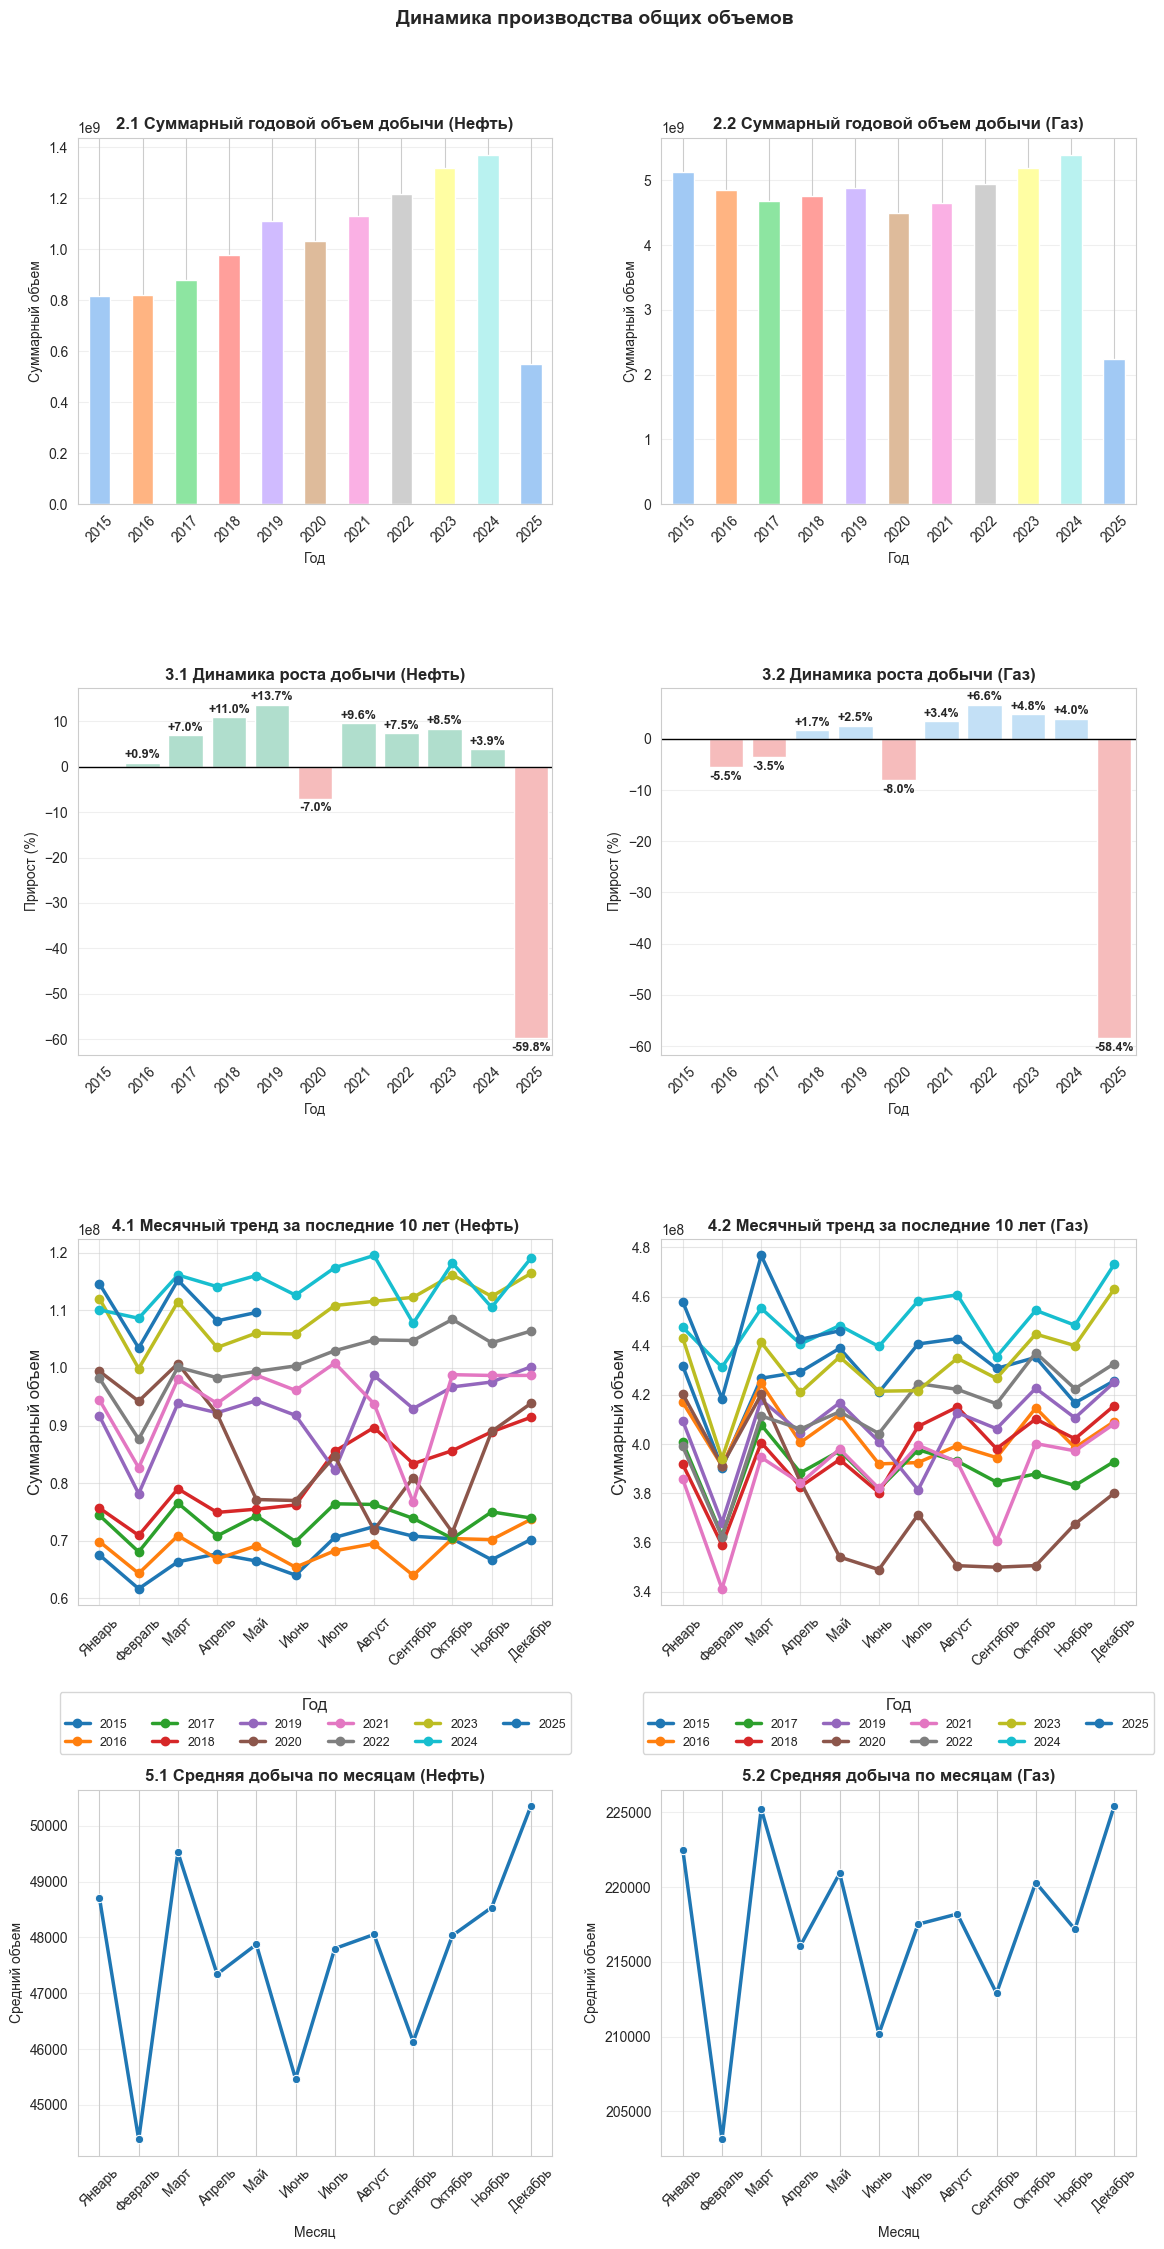

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(12, 22))
fig.suptitle('Динамика производства общих объемов', fontsize=14, y=1.02, fontweight='bold')

# Предварительные расчеты
oil_df['Year'] = oil_df['Production Date'].dt.year
gas_df['Year'] = oil_df['Production Date'].dt.year

annual_oil = oil_df.groupby('Year')['Volume'].sum()
annual_gas = gas_df.groupby('Year')['Volume'].sum()

yoy_oil = annual_oil.pct_change() * 100
yoy_gas = annual_gas.pct_change() * 100

# График 1.1: Объемы нефти
annual_oil.plot(kind="bar", ax=axes[0,0], color=pastel_palette)
axes[0,0].set_title("2.1 Суммарный годовой объем добычи (Нефть)", fontsize=12, fontweight='bold')
axes[0,0].set_ylabel("Суммарный объем")
axes[0,0].set_xlabel("Год")
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', alpha=0.3)

# График 1.2: Объемы газа
annual_gas.plot(kind="bar", ax=axes[0,1], color=pastel_palette)
axes[0,1].set_title("2.2 Суммарный годовой объем добычи (Газ)", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("Суммарный объем")
axes[0,1].set_xlabel("Год")
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)

# График 2.1: Динамика нефти
colors_oil = ['#FFB3B3' if x < 0 else '#A8E6CF' for x in yoy_oil.values]
if not yoy_oil.empty:
    sns.barplot(x=yoy_oil.index, y=yoy_oil.values, ax=axes[1,0], palette=colors_oil)
    axes[1,0].set_title("3.1 Динамика роста добычи (Нефть)", fontsize=12, fontweight='bold')
    axes[1,0].set_ylabel("Прирост (%)")
    axes[1,0].set_xlabel("Год")
    axes[1,0].axhline(0, color='black', linestyle='-', linewidth=1)
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,0].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(yoy_oil.values):
        if not np.isnan(v):
            va_position = 'bottom' if v >= 0 else 'top'
            y_offset = 0.3 if v >= 0 else -0.8
            axes[1,0].text(i, v + y_offset, f'{v:+.1f}%', 
                          ha='center', va=va_position, fontweight='bold', fontsize=9)

# График 2.2: Динамика газа
colors_gas = ['#FFB3B3' if x < 0 else '#BAE1FF' for x in yoy_gas.values]
if not yoy_gas.empty:
    sns.barplot(x=yoy_gas.index, y=yoy_gas.values, ax=axes[1,1], palette=colors_gas)
    axes[1,1].set_title("3.2 Динамика роста добычи (Газ)", fontsize=12, fontweight='bold')
    axes[1,1].set_ylabel("Прирост (%)")
    axes[1,1].set_xlabel("Год")
    axes[1,1].axhline(0, color='black', linestyle='-', linewidth=1)
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(yoy_gas.values):
        if not np.isnan(v):
            va_position = 'bottom' if v >= 0 else 'top'
            y_offset = 0.3 if v >= 0 else -0.8
            axes[1,1].text(i, v + y_offset, f'{v:+.1f}%', 
                          ha='center', va=va_position, fontweight='bold', fontsize=9)
            
# Предварительные расчеты
oil_df['Month'] = oil_df['Production Date'].dt.month_name()
gas_df['Month'] = gas_df['Production Date'].dt.month_name()

monthly_trend_oil = (
    oil_df.groupby(['Year', 'Month'])['Volume']
    .sum()
    .reset_index()
    .pivot(index='Month', columns='Year', values='Volume')
    .rename(index=month_dict)  
    .reindex(month_order_ru))

monthly_trend_gas = (
    gas_df.groupby(['Year', 'Month'])['Volume']
    .sum()
    .reset_index()
    .pivot(index='Month', columns='Year', values='Volume')
    .rename(index=month_dict)
    .reindex(month_order_ru))

# График 3: Месячный тренд за последние 10 лет
for year in monthly_trend_oil.columns:
        axes[2,0].plot(monthly_trend_oil.index, monthly_trend_oil[year],
                 marker='o', linewidth=2.5, linestyle='-', label=str(year),)
        axes[2,1].plot(monthly_trend_gas.index, monthly_trend_gas[year],
                 marker='o', linewidth=2.5, linestyle='-', label=str(year))

axes[2,0].set_title('4.1 Месячный тренд за последние 10 лет (Нефть)',
            fontsize=12, weight='bold')
axes[2,0].set_ylabel('Суммарный объем', fontsize=12)
axes[2,0].tick_params(axis='x', rotation=45)
axes[2,0].grid(True, linestyle='-', alpha=0.5)

axes[2,0].legend(title='Год', fontsize=9, title_fontsize=12,
            loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)

axes[2,1].set_title('4.2 Месячный тренд за последние 10 лет (Газ)',
            fontsize=12, weight='bold')
axes[2,1].set_ylabel('Суммарный объем', fontsize=12)
axes[2,1].tick_params(axis='x', rotation=45)
axes[2,1].grid(True, linestyle='-', alpha=0.5)

axes[2,1].legend(title='Год', fontsize=9, title_fontsize=12,
            loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=6)

oil_monthly_avg = (oil_df.groupby('Month')['Volume']
                   .mean()
                   .rename(index=month_dict)  # заменяем английские на русские
                   .reindex(month_order_ru))  # упорядочиваем по-русски

gas_monthly_avg = (gas_df.groupby('Month')['Volume']
                   .mean()
                   .rename(index=month_dict)  # заменяем английские на русские
                   .reindex(month_order_ru))  # упорядочиваем по-русски

# График 4.1: Средняя добыча по месяцам (Нефть)
sns.lineplot(x=oil_monthly_avg.index, y=oil_monthly_avg.values, marker='o', linewidth=2.5, linestyle='-', palette='pastel', ax=axes[3,0])
axes[3,0].set_title("5.1 Средняя добыча по месяцам (Нефть)", fontsize=12, fontweight='bold')
axes[3,0].set_ylabel("Средний объем")
axes[3,0].set_xlabel("Месяц")
axes[3,0].tick_params(axis='x', rotation=45)
axes[3,0].grid(axis='y', alpha=0.3)

# График 4.2: Средняя добыча по месяцам (Газ)
sns.lineplot(x=gas_monthly_avg.index, y=gas_monthly_avg.values, marker='o', linewidth=2.5, linestyle='-', palette='pastel', ax=axes[3,1])
axes[3,1].set_title("5.2 Средняя добыча по месяцам (Газ)", fontsize=12, fontweight='bold')
axes[3,1].set_ylabel("Средний объем")
axes[3,1].set_xlabel("Месяц")
axes[3,1].tick_params(axis='x', rotation=45)
axes[3,1].grid(axis='y', alpha=0.3)

print("\nСВОДНАЯ СТАТИСТИКА")
print("="*50)

print(f"• За весь период 2015-2025 произведено объемов: "
            f"Нефть = {annual_oil.sum():,.0f} BBL, Газ = {annual_gas.sum():,.0f} MCF.\n")

print(f"• Нефть - пиковый год: {annual_oil.idxmax()} ({annual_oil.max():,.0f} BBL)")
print(f"• Газ - пиковый год: {annual_gas.idxmax()} ({annual_gas.max():,.0f} MCF)")

print("\nСРЕДНИЙ ГОДОВОЙ ПРИРОСТ:")

print(f"• Нефть: {yoy_oil.mean():+.1f}% BBL")
print(f"• Газ: {yoy_gas.mean():+.1f}% MCF\n")

plt.tight_layout()
plt.show()

## Анализ целевой переменной по типу ресурса (Нефть, Газ) во времени

### 1. Суммарные годовые объёмы добычи
- **Нефть 🛢️:** с 2015 по 2024 наблюдается устойчивый рост совокупного годового объёма добычи — примерно с 0.8 млрд до 1.35 млрд единиц.  
- **Газ 🔥:** аналогично, умеренный рост с 5.0 млрд до 5.4 млрд единиц за тот же период.  
- **2025 год** показывает резкое снижение объёмов добычи по обоим видам ресурсов. Это объясняется **неполнотой данных за текущий год**, поэтому отклонение не следует рассматривать как фактическое падение добычи.

### 2. Динамика роста добычи
- **Нефть 🛢️:** положительные темпы прироста в среднем 3–13% в год, с временным снижением в 2020 году (~–7%).  
- **Газ 🔥:** умеренные колебания в диапазоне ±5% до 2024 года.  
- **2025 год** фиксирует отрицательные приросты (около –60%) вследствие частичной представленности данных.

### 3. Месячные тренды за последние 10 лет
- **Нефть 🛢️:** сезонность повторяется ежегодно — минимальные значения добычи наблюдаются в феврале, максимальные — в декабре.  
- **Газ 🔥:** сезонный характер аналогичен: спад в феврале, рост в марте и декабре.  
- Общая структура месячных колебаний остаётся стабильной на протяжении десятилетия.

### 4. Средняя добыча по месяцам
- **Нефть 🛢️:** подтверждает выраженную сезонность — декабрь показывает наибольшие объёмы, февраль — минимальные.  
- **Газ 🔥:** демонстрирует схожий профиль: пиковые значения приходятся на март и декабрь.

### 5. Общие выводы
1. С 2015 по 2024 годы наблюдается **устойчивый рост добычи** нефти и газа с умеренными колебаниями.  
2. **Сезонность выражена отчётливо**: февральские минимумы и декабрьские пики характерны для обоих типов ресурсов.  
3. **Данные за 2025 год неполные**, поэтому резкое снижение объёмов и темпов роста не отражает фактических тенденций.  


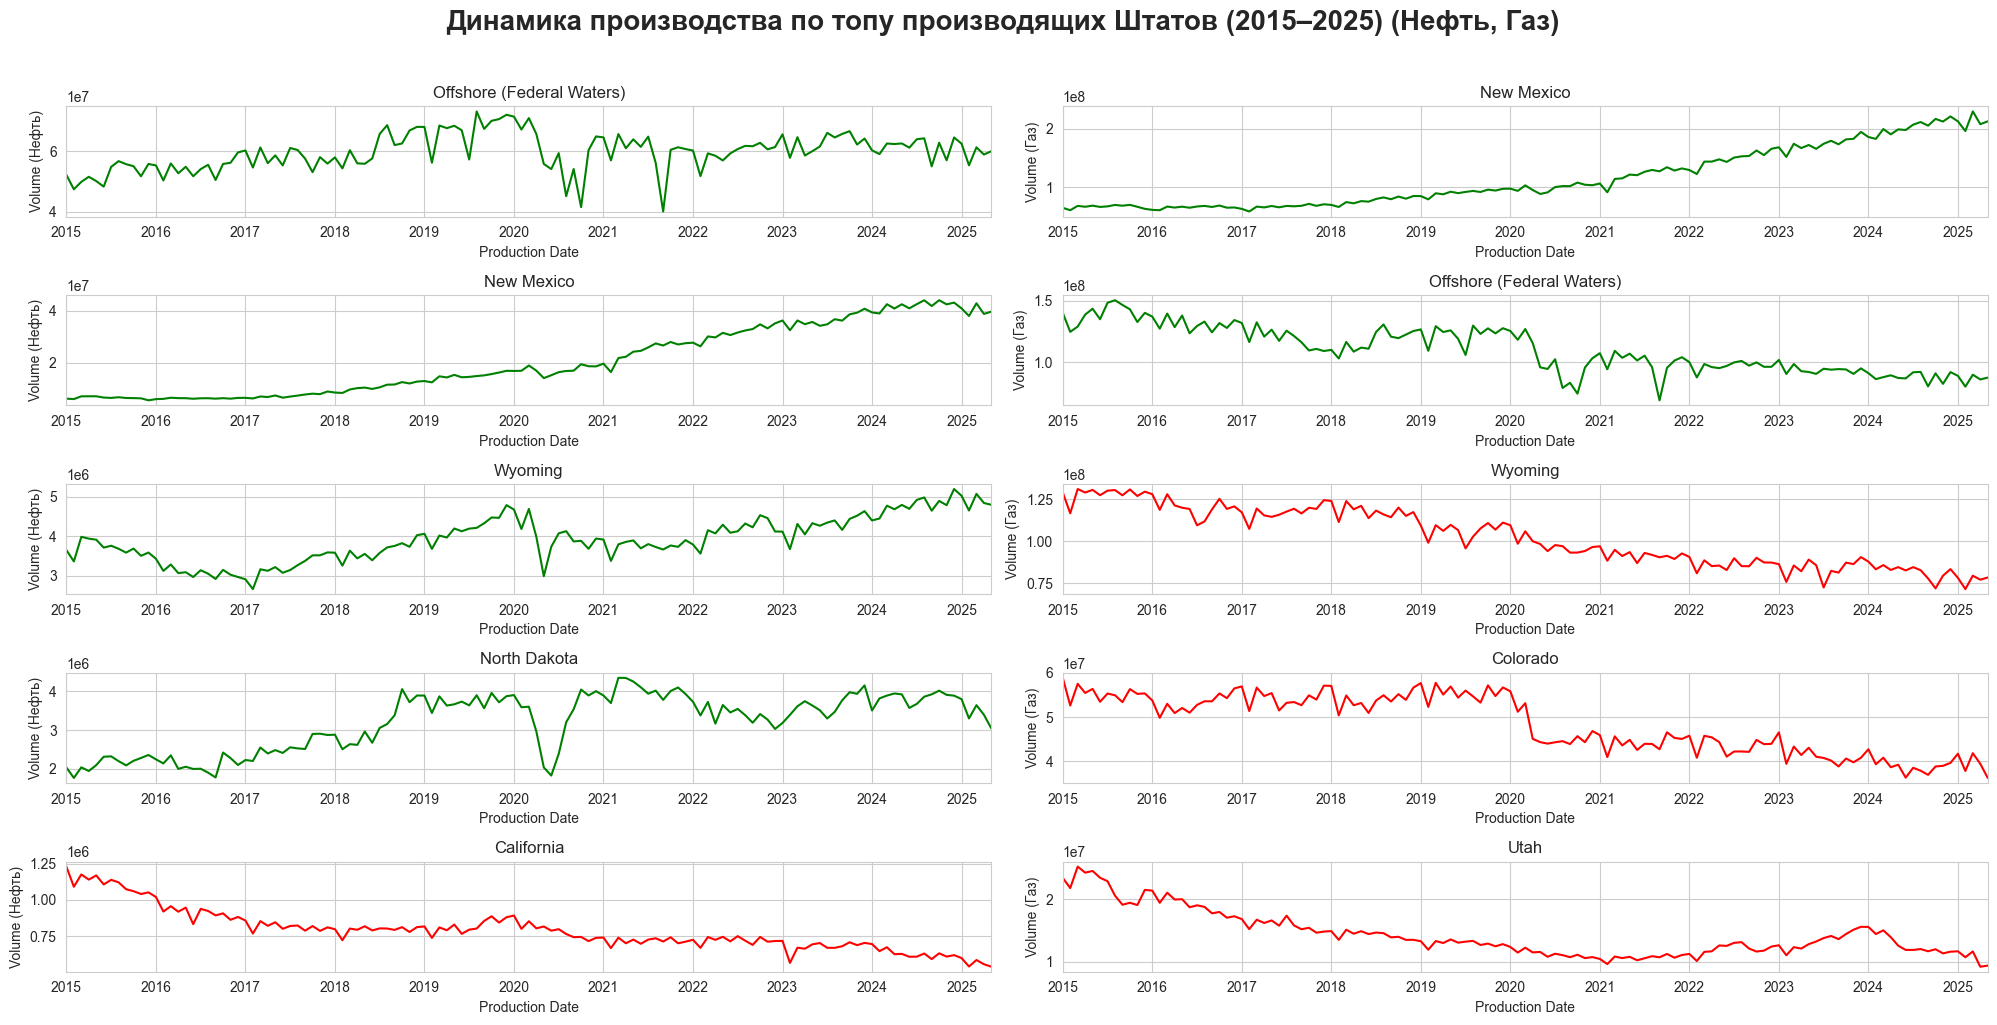

In [11]:
top_states_oil = oil_df.groupby('State')['Volume'].sum().nlargest(5).index
top_states_gas = gas_df.groupby('State')['Volume'].sum().nlargest(5).index

fig, axes = plt.subplots(5, 2, figsize=(20, 10))
fig.suptitle('Динамика производства по топу производящих Штатов (2015–2025) (Нефть, Газ)', fontsize=20, y=1.02, fontweight='bold')

for i, state in enumerate(top_states_oil):

    state_data = oil_df[oil_df['State'] == state]
    monthly = state_data.groupby(pd.Grouper(key='Production Date', freq='M'))['Volume'].sum()
    
    monthly.plot(ax=axes[i][0], title=f'{state}', color='red' if monthly.pct_change().mean() < 0 else 'green')

    axes[i][0].set_ylabel('Volume (Нефть)')
    
for i, state in enumerate(top_states_gas):

    state_data = gas_df[gas_df['State'] == state]
    monthly = state_data.groupby(pd.Grouper(key='Production Date', freq='M'))['Volume'].sum()
    
    monthly.plot(ax=axes[i][1], title=f'{state}', color='red' if monthly.pct_change().mean() < 0 else 'green')

    axes[i][1].set_ylabel('Volume (Газ)')

plt.tight_layout()
plt.show()

state_totals_oil = oil_df.groupby('State')['Volume'].sum().reset_index()

state_totals_oil['State'].replace(state_map_inv, inplace=True)

state_totals_gas = gas_df.groupby('State')['Volume'].sum().reset_index()

state_totals_gas['State'].replace(state_map_inv, inplace=True)

fig_oil = px.choropleth(state_totals_oil,
                    locations='State',
                    locationmode='USA-states',
                    color='Volume',
                    color_continuous_scale='Viridis',
                    scope="usa",
                    title="Нефть - Суммарное производство по Штатам")

fig_gas = px.choropleth(state_totals_gas,
                    locations='State',
                    locationmode='USA-states',
                    color='Volume',
                    color_continuous_scale='Viridis',
                    scope="usa",
                    title="Газ - Суммарное производство по Штатам")

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Нефть", "Газ"),
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]]
)

for trace in fig_oil.data:
    fig.add_trace(trace, row=1, col=1)
    
for trace in fig_gas.data:
    fig.add_trace(trace, row=1, col=2)

fig.update_layout(
    title_text="Суммарное производство по Штатам (2015–2025)",
    width=1075,
    height=500
)

fig.update_geos(scope="usa", row=1, col=1)
fig.update_geos(scope="usa", row=1, col=2)

fig.show()

## Динамика производства по топу производящих Штатов

---

### Основные наблюдения (нефть)
- **Offshore (Federal Waters):** относительная стабильность с флуктуациями, заметные провалы в периоды 2020–2021 — характерно для шоковых событий и остановок на шельфе; после 2021 — частичное восстановление, но волатильность сохраняется.  
- **New Mexico:** чётко выраженный устойчивый рост с 2018 года; скорость наращивания объёма высокая — регион является основным драйвером увеличения нефтедобычи в рассматриваемый период.  
- **Wyoming:** после падения в середине 2010-х наблюдается восстановление с пиком около 2019 и временным спадом в 2020; затем постепенный рост до 2024–2025.  
- **North Dakota:** рост до 2019, резкое снижение в 2020 (вплоть до глубокого провала), затем неполное восстановление и волатильность в конце периода.  
- **California:** устойчивое снижение объёмов за весь период; тренд явно нисходящий.

### Основные наблюдения (газ)
- **New Mexico (газ):** сильный устойчивый рост с ≈2018—2019 гг., демонстрирует значимый вклад в общий объём газовой добычи; тенденция к дальнейшему увеличению до 2024–2025.  
- **Offshore (Federal Waters) — газ:** противоположная динамика: более высокие значения в начале периода и постепенное снижение/флуктуации после 2016–2018; выраженные провалы в 2020–2021.  
- **Wyoming (газ):** монотонное снижение объёмов на протяжении периода; нет признаков устойчивого восстановления к 2024.  
- **Colorado:** относительная стабильность с тенденцией к снижению после 2019–2020; видимы краткосрочные колебания.  
- **Utah:** общий нисходящий тренд, с незначительными локальными подъёмами (примерно 2022–2023), затем снижение.

---

### Типичные драйверы наблюдаемых паттернов
- **Региональные инвестиции и бурение:** буровая активность в New Mexico (сланцевые операторы) объясняет устойчивый рост.  
- **Офшорные факторы:** сезоны ураганов, регуляторные и техобслуживание приводят к высокой волатильности на шельфе.  
- **Системные шоки:** заметный пробой в 2020 — вероятно эффект COVID-19 и ценовых шоков, локальные остановки площадок.  
- **Долгосрочная деградация:** в некоторых штатах (California (нефть), Wyoming (газ)) видно сокращение запасов/снижение активности.

Аномалии для (Нефть):
Production Date
2019-07-01   -1.136380e+07
2020-05-01   -9.133953e+06
2020-08-01   -1.450476e+07
2020-10-01   -1.337632e+07
2021-09-01   -1.521003e+07
Name: resid, dtype: float64
Всего аномалий: 5
--------------------------------------------------
Аномалии для (Газ):
Production Date
2019-07-01   -2.691684e+07
2020-02-01    2.336842e+07
2020-05-01   -2.803766e+07
2020-08-01   -2.272530e+07
2020-10-01   -2.119182e+07
2021-09-01   -2.168332e+07
Name: resid, dtype: float64
Всего аномалий: 6
--------------------------------------------------


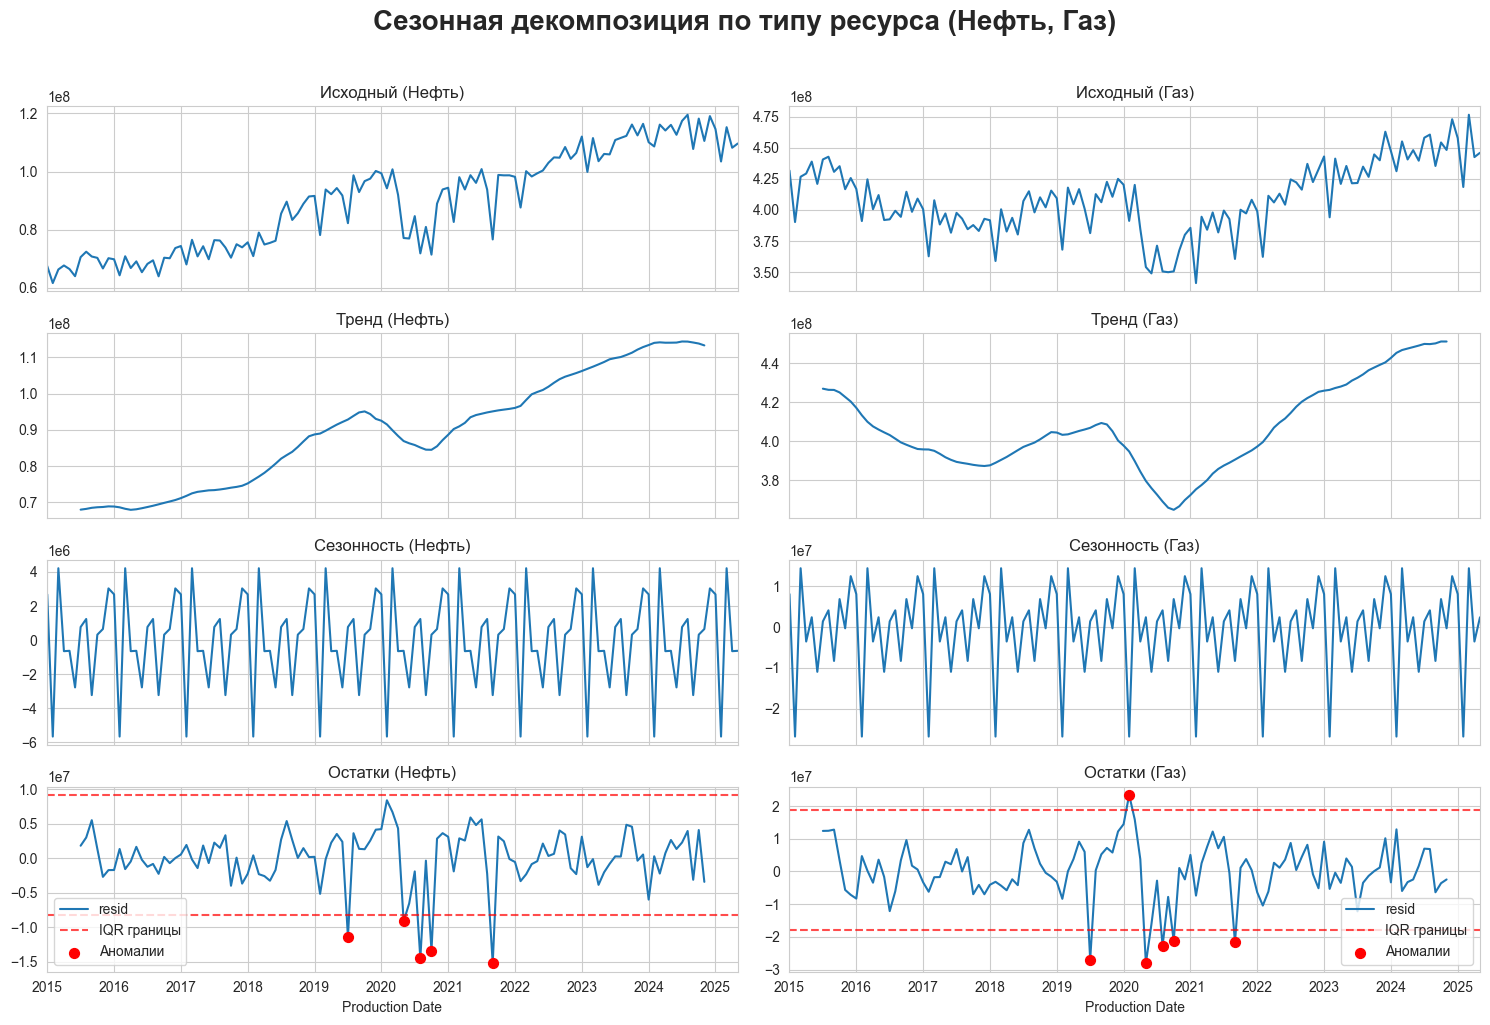

In [12]:
def plotseasonal(res, axes, commodity):
    """
    Визуализирует результаты сезонной декомпозиции временного ряда 
    и выделяет статистические аномалии в остатках.

    Функция строит четыре графика компонент декомпозиции и автоматически
    определяет выбросы в остатках методом межквартильного размаха (IQR).

    Параметры
    ----------
    res : объект результата сезонной декомпозиции
        Объект, содержащий декомпозированные компоненты временного ряда.
        Ожидаются атрибуты:
        - observed: исходный временной ряд
        - trend: трендовая составляющая
        - seasonal: сезонная составляющая
        - resid: остатки (шумовая составляющая)
    
    axes : list или array of matplotlib.axes.Axes
        Массив из четырех осей matplotlib для построения графиков.
        Порядок осей должен соответствовать:
        [0] - исходный ряд
        [1] - тренд
        [2] - сезонность
        [3] - остатки с аномалиями
    
    commodity : str
        Название анализируемого товара/актива, используемое в заголовках
        графиков и выводе статистики.

    Возвращает
    -------
    None
        Функция выполняет построение графиков и вывод статистики в консоль.
    """

    res.observed.plot(ax=axes[0], legend=False)
    axes[0].set_title(f'Исходный {commodity}')
    res.trend.plot(ax=axes[1], legend=False)
    axes[1].set_title(f'Тренд {commodity}')
    res.seasonal.plot(ax=axes[2], legend=False)
    axes[2].set_title(f'Сезонность {commodity}')
    res.resid.plot(ax=axes[3], legend=False)
    axes[3].set_title(f'Остатки {commodity}')
    
    Q1 = res.resid.quantile(0.25)
    Q3 = res.resid.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Рисуем границы IQR
    axes[3].axhline(y=lower_bound, color='r', linestyle='--', alpha=0.7, label=f'IQR границы')
    axes[3].axhline(y=upper_bound, color='r', linestyle='--', alpha=0.7)
    
    # Находим выбросы
    outliers_iqr = res.resid[(res.resid < lower_bound) | (res.resid > upper_bound)]
    
    # Выделяем выбросы красными точками на графике residual
    axes[3].scatter(outliers_iqr.index, outliers_iqr.values, 
                   color='red', s=50, zorder=5, label='Аномалии')
    
    # Добавляем легенду только для residual графика
    axes[3].legend()
    
    print(f"Аномалии для {commodity}:")
    print(outliers_iqr)
    print(f"Всего аномалий: {len(outliers_iqr)}")
    print("-" * 50)

result_oil = seasonal_decompose(oil_df.groupby('Production Date')['Volume'].sum().sort_index(), model='additive', period=12)
result_gas = seasonal_decompose(gas_df.groupby('Production Date')['Volume'].sum().sort_index(), model='additive', period=12)

fig, axes = plt.subplots(ncols=2, nrows=4, sharex=True, figsize=(15, 10))
fig.suptitle('Сезонная декомпозиция по типу ресурса (Нефть, Газ)', fontsize=20, y=1.02, fontweight='bold')

plotseasonal(result_oil, axes[:,0], '(Нефть)')
plotseasonal(result_gas, axes[:,1], '(Газ)')

plt.tight_layout()
plt.show()

## ⏱ Временная динамика
- **Тренд:** наблюдается **долгосрочный рост добычи** (рост отчётного объёма) с просадками в 2020 году, неполные данные за 2025 год.  
- **Сезонность:** присутствует **годовая компонента** с периодом ≈ **12 месяцев**.  
- **Остатки (residuals):** показывают **нерегулярные колебания**, что может указывать на краткосрочные корректировки или операционные аномалии.

- 👉 Экстремально высокие значения в большинстве своем свидетельствуют о корректировках завышенных объемов. Единственный положительный выброс наблюдается у производства газа (Эпидемия Covid, 2020 год), скорее всего планировалось, что уровень производства исходя от тренда будет расти, но из-за глобального кризиса, пришлось существенно корректироваться, что можно наблюдать на кривой residual.

# Анализ временных рядов добычи нефти и газа

In [13]:
def plot_strutural_breaks(series, model, pen, commodity, dates=None):
    """
    Функция для обнаружения и визуализации структурных сдвигов
    
    Параметры:
    -----------
    series : array-like
        Временной ряд или матрица признаков
    model : str
        Модель для ruptures ('linear', 'l2', 'rbf', etc.)
    pen : float
        Параметр штрафа для алгоритма
    commodity : str
        Название ресурса
    dates : array-like, optional
        Даты для оси X

    Возвращает
    -------
    breaks: array-like
        Индексы точек структрных сдвигов временного ряда.
    """

    # Пример: анализируем общий уровень добычи (или можно отдельно нефть/газ)
    series_data = series.copy() 

    # Алгоритм поиска сдвигов по среднему и тренду
    algo = rpt.Pelt(model=model).fit(series_data)

    # Указываем желаемое количество сдвигов (например, до 3)
    breaks = algo.predict(pen=pen)

    # Визуализация
    fig, ax = plt.subplots(figsize=(20, 6))

    # Отображаем исходные данные
    ax.plot(series, 'b-', linewidth=1)

    # исключаем последний элемент (конец ряда)
    breaks =  breaks[:-1]

    # Добавляем вертикальные линии для разладок
    for br in breaks: 
        ax.axvline(x=br, color='red', linestyle='--', alpha=0.7, linewidth=1)

    # Добавляем закрашенные области между разладками
    colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightpink', 'lightgray']
    for i in range(len(breaks)-1):
        start = breaks[i]
        end = breaks[i+1]
        if i < len(colors):
            ax.axvspan(start, end, alpha=0.2, color=colors[i])

    # Настраиваем оси
    if dates is not None and len(dates) == len(series_data):
        # Показываем каждую N-ую дату для читаемости
        step = max(1, len(dates) // 15)
        indices = range(0, len(dates), step)
        ax.set_xticks(indices)
        ax.set_xticklabels([str(dates[i])[:10] for i in indices], 
                          rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('Дата')
    else:
        ax.set_xlabel('Индекс наблюдения')

    ax.set_ylabel(f'Объем добычи {commodity}')
    ax.set_title(f"Структурные сдвиги в добыче {commodity} (Модель: {model}, Penalty: {pen})")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    return breaks

Месячные объемы
Размерность данных (Нефть): (125, 2)
Размерность данных (Газ): (125, 2)
Период данных: 2015-01-01 00:00:00 - 2025-05-01 00:00:00
• Проверка временных рядов на стационарность:
Результаты проверки стационарности oil:

Уровень значимости: 0.05
Тест Дики-Фуллера (ADF): pvalue= 0.6085
Тест KPSS: p-value = 0.1000
Вывод: Результаты противоречивы oil

Результаты проверки стационарности gas:

Уровень значимости: 0.05
Тест Дики-Фуллера (ADF): pvalue= 0.7387
Тест KPSS: p-value = 0.0100
Вывод: Ряд нестационарен (тренд) gas

• Тест Грейнджера на причинно-следственную связь (предсказывает ли газ объемы нефти?):

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=11.8171 , p=0.0008  , df_denom=121, df_num=1
ssr based chi2 test:   chi2=12.1101 , p=0.0005  , df=1
likelihood ratio test: chi2=11.5546 , p=0.0007  , df=1
parameter F test:         F=11.8171 , p=0.0008  , df_denom=121, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.2

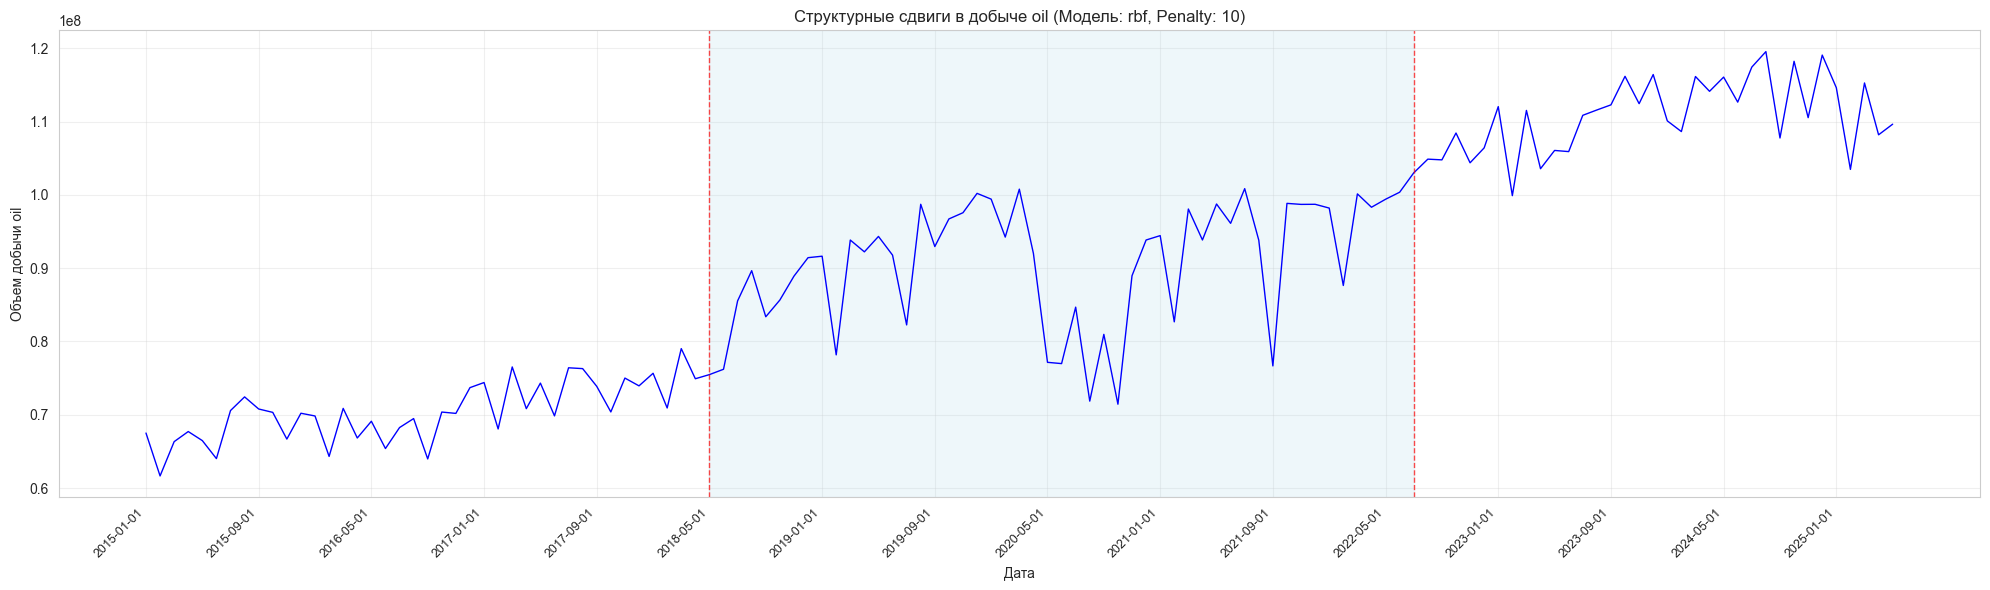

Даты структурных сдвигов Oil: ['2018-05-01T00:00:00.000000000' '2022-07-01T00:00:00.000000000']


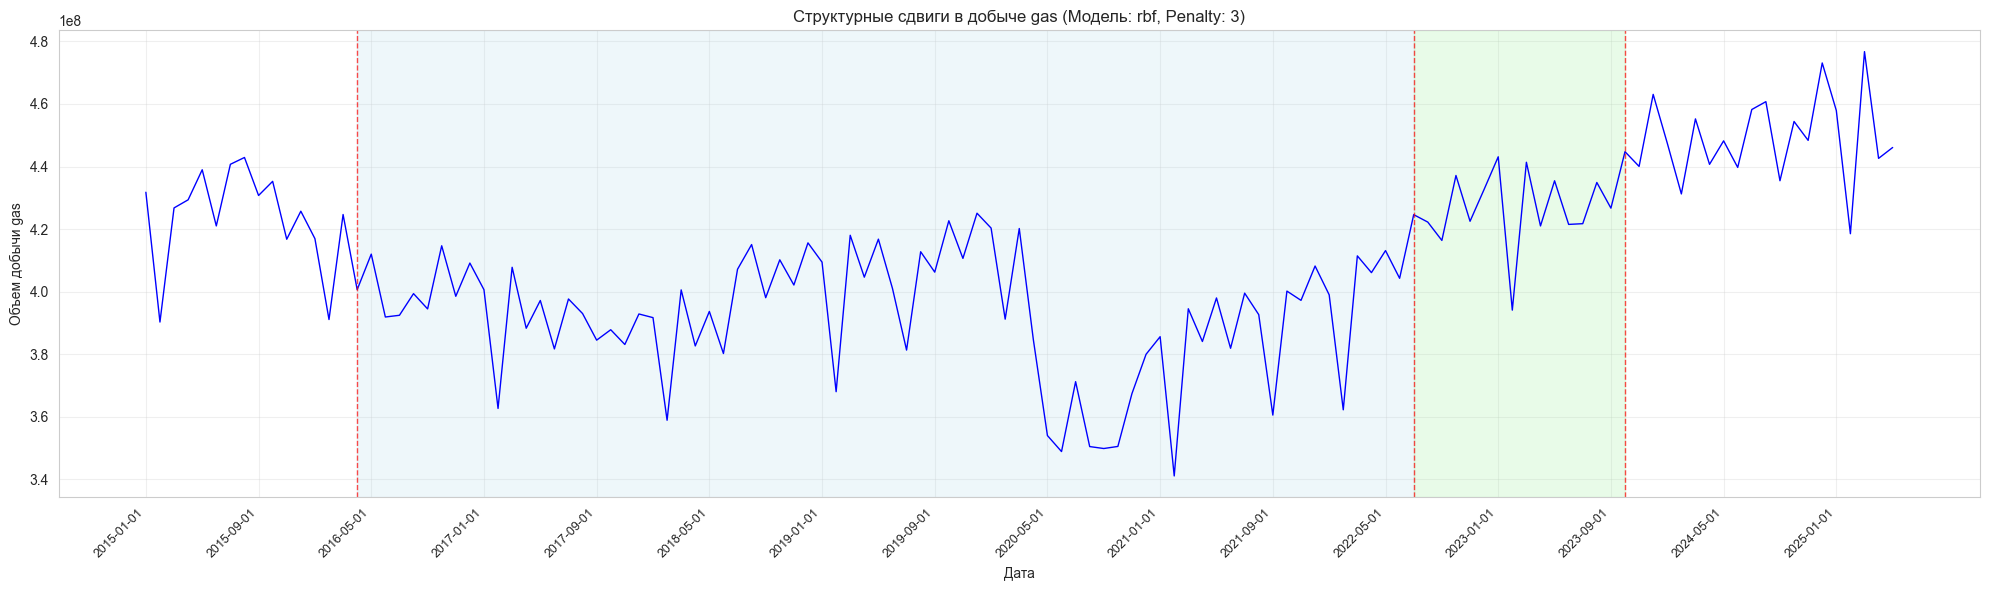

Даты структурных сдвигов Gas: ['2016-04-01T00:00:00.000000000' '2022-07-01T00:00:00.000000000'
 '2023-10-01T00:00:00.000000000']


In [14]:
oil_monthly = oil_df.groupby('Production Date', as_index=False)['Volume'].sum()
gas_monthly = gas_df.groupby('Production Date', as_index=False)['Volume'].sum()

oil_monthly = oil_monthly.rename(columns={'Production Date': 'period'})
gas_monthly = gas_monthly.rename(columns={'Production Date': 'period'})

print("=" * 70)
print("Месячные объемы")
print("=" * 70)
print(f'Размерность данных (Нефть): {oil_monthly.shape}')
print(f'Размерность данных (Газ): {gas_monthly.shape}')
print(f'Период данных: {oil_monthly["period"][0]} - {oil_monthly["period"].iloc[-1]}')

print("=" * 70)

print("=" * 70)
print("• Проверка временных рядов на стационарность:")
print("=" * 70)
check_stationarity(oil_monthly['Volume'], commodity='oil')
check_stationarity(gas_monthly['Volume'], commodity='gas')

print("=" * 70)
print("• Тест Грейнджера на причинно-следственную связь (предсказывает ли газ объемы нефти?):") 
print("=" * 70)
grangercausalitytests(pd.concat([oil_monthly['Volume'], gas_monthly['Volume']], axis=1), maxlag=12, verbose=True)
print("=" * 70)

print("=" * 70)
print("• Тест Грейнджера на причинно-следственную связь (предсказывает ли нефть объемы газа?):") 
print("=" * 70)
grangercausalitytests(pd.concat([gas_monthly['Volume'], oil_monthly['Volume']], axis=1), maxlag=12, verbose=True)
print("=" * 70)

print("=" * 70)
print("• Проверка временных рядов на конинтеграцию:")
print("=" * 70)
result = coint_johansen(pd.concat([oil_monthly['Volume'], gas_monthly['Volume']], axis=1), det_order=0, k_ar_diff=1)

# Cтатистика теста
print("Trace Stat:", result.lr1)
print("Critical Values (90%, 95%, 99%):", result.cvt)

# Вывести статистику максимального собственного значения
print("Max-Eig Stat:", result.lr2)
print("Critical Values (90%, 95%, 99%):", result.cvm)

print("=" * 70)
print("• Проверка временных рядов на сутруктурные сдвиги:")
print("=" * 70)

breaks_oil = plot_strutural_breaks(oil_monthly['Volume'].values, 'rbf', pen=10, dates=oil_monthly['period'], commodity='oil')
print(f'Даты структурных сдвигов Oil: {oil_monthly["period"].iloc[breaks_oil].values}')
breaks_gas = plot_strutural_breaks(gas_monthly['Volume'].values, 'rbf', pen=3, dates=gas_monthly['period'], commodity='gas')
print(f'Даты структурных сдвигов Gas: {gas_monthly["period"].iloc[breaks_gas].values}')

# Вывод по результатам анализа временных рядов добычи нефти и газа

## 1. Общая характеристика данных
- Исходные данные охватывают период **с января 2015 по май 2025 года** с месячной частотой.  
- Анализ проводился по двум временным рядам: **`Oil` (объёмы добычи нефти)** и **`Gas` (объёмы добычи газа)**.  
- После агрегации по месяцам размерность составила 125 наблюдений для каждого ряда.

---

## 2. Проверка статистических свойств рядов

### 1. Стационарность
- Тесты ADF и KPSS показали противоречивые, но типичные для трендовых рядов результаты:
  - оба ряда содержат **трендовую нестационарность**;

---

## 2. Краткосрочные взаимосвязи: тест Грейнджера
- Тест Грейнджера (`maxlag=12`) показал статистически значимую причинную связь:
  - на лагах **1, 4–6, 12 месяцев** переменная `Gas` **Грейнджер-предсказывает** `Oil`;
  - влияние `Oil` на `Gas` выражено слабее и неустойчиво.
- Вывод: существует **асимметричная краткосрочная зависимость**, при которой изменения в добыче газа предшествуют изменениям в добыче нефти с задержкой до года.

---

## 3. Долгосрочные взаимосвязи: тест Джохансена
- Результаты теста коинтеграции Джохансена:
  ```
  Trace Stat: [9.25, 3.11]
  Critical Values (95%): [15.49, 3.84]
  ```
  → нулевая гипотеза об отсутствии коинтеграции **не отвергается**.
- Следовательно, **долгосрочной устойчивой связи между нефтью и газом не выявлено**.
- Это означает, что модели типа **VECM** неприменимы, а адекватным выбором является **VAR на разностях**.

---

## 5. Структурные сдвиги (`ruptures`)
- Анализ структурных сдвигов показал, что обе серии претерпели **существенные изменения режима**:

  | Переменная | Даты сдвигов |
  |-------------|--------------|
  | **Oil** | 2018-05-01, 2022-07-01 |
  | **Gas** | 2016-04-01, 2022-07-01, 2023-10-01 |

- Совпадающий сдвиг **в июле 2022 года** указывает на **общий экзогенный шок**, вероятно связанный с изменением внешних условий добычи, спроса или политики.  
- После 2022 года обе серии демонстрируют новый устойчивый уровень и изменившуюся динамику, что подтверждает необходимость **моделировать их отдельно в новом режиме**.

---

## 6. Решение о сегментировании и выборе периода моделирования
- На основе анализа сдвигов принято решение:
  - **разделить временные ряды по дате `2022-07-01`**;
  - использовать **последний сегмент (2022-07 → 2025-05)** для обучения и прогнозирования.
- Этот сегмент отражает **актуальное состояние системы** и обеспечивает релевантные параметры для прогноза будущих объёмов.
- Несмотря на ограниченное число наблюдений (~34 точки), при выборе небольшого количества лагов (≤ 2) и проверке устойчивости модели **VAR остаётся применимой**.

---

## 7. План моделирования
1. Проверить стационарность сегмента `2022-07 → 2025-05`.  
   При необходимости использовать первые разности (`diff()`).
2. Обучить **VAR**.  
3. Проверить устойчивость модели (`is_stable()`).
4. Сравнить прогнозные метрики с альтернативами:
   - **Exponential Smoothing (ETS)**,
   - **Prophet**.
---

##  <center> 🔍 Итоговый аналитический блок (EDA) </center>

# Финальные выводы по результатам EDA

## 1. Характеристика исходных данных
Исходный датасет охватывает период **с января 2015 по май 2025 года** и содержит **470 830 записей** с детализацией по:
- типу ресурса (нефть / газ),
- географии (штаты, округа, офшорные регионы),
- типам операций (Disposition Code / Description),
- объёмам добычи и корректировок.

Данные являются **административной отчётностью (OGOR)**, что накладывает особенности интерпретации: часть записей отражает не физическую добычу, а **учётные, корректировочные и нулевые операции**.

---

## 2. Распределение объёмов и необходимость агрегации
Анализ неагрегированных объёмов показал:

- экстремально высокий разброс значений;
- наличие значительных выбросов;
- доминирование нулевых значений.

Доля записей по типу объёма:
- **Нефть:**  
  - 80.3% — нулевые,  
  - 2.2% — отрицательные,  
  - 17.5% — положительные.
- **Газ:**  
  - 45.7% — нулевые,  
  - 3.3% — отрицательные,  
  - 51.0% — положительные.

**Вывод:**  
Анализ и моделирование по «сырым» операциям некорректны. Для выявления экономически осмысленных закономерностей необходимо **агрегировать данные по времени**, в частности — **по месяцам**.

---

## 3. Экономическая интерпретация операций OGOR
Анализ типов операций позволил разделить их на три категории:

- **Positive** — формируют фактическую добычу и базу для роялти;
- **Negative** — корректировки предыдущих периодов (менее 3% записей);
- **Zero** — технологические и отчётные операции без товарного выхода.

Выявлены принципиальные различия бизнес-моделей:
- **Нефть** ориентирована на **прямую продажу или хранение перед продажей**;
- **Газ** преимущественно **направляется на переработку** (Transferred to Facility).

Это подтверждает, что нефть и газ являются **структурно разными продуктами**, несмотря на общую отрасль.

---

## 4. Пространственная структура добычи
Ключевые закономерности:

- Более **90% добычи** нефти и газа приходится на **федеральные земли**.
- **Нефть**:
  - преимущественно **offshore**,
  - основной вклад — **Offshore Gulf**.
- **Газ**:
  - преимущественно **onshore**,
  - ключевые регионы — **New Mexico**, **Wyoming**.

Пространственная концентрация выражена сильно: **несколько штатов и регионов формируют основную часть объёма**.

---

## 5. Долгосрочная динамика и сезонность
Агрегированные временные ряды (месячная частота) показали:

- **устойчивый рост** добычи нефти и газа в 2015–2024 гг.;
- резкий спад в 2020 году, совпадающий с глобальным экономическим шоком;
- выраженную **годовую сезонность**:
  - минимумы — февраль,
  - максимумы — декабрь / март.

Падение в 2025 году объясняется **неполнотой данных**, а не реальным снижением добычи.

---

## 6. Региональная динамика
Региональный анализ выявил различные режимы:

- **New Mexico** — основной драйвер роста и для нефти, и для газа;
- **Offshore (Federal Waters)** — высокая волатильность, чувствительность к внешним шокам;
- **California (нефть)** и **Wyoming (газ)** — устойчивый нисходящий тренд, вероятно связанный с истощением запасов и регуляторными ограничениями.

---

## 7. Временные ряды и их свойства
Анализ временных рядов показал:

- наличие **трендовой нестационарности**;
- выраженную сезонную компоненту с периодом 12 месяцев;
- нерегулярные остатки, связанные с корректировками и внешними шоками.

---

## 8. Взаимосвязь нефти и газа
Результаты эконометрических тестов:

- **Тест Грейнджера**:
  - добыча газа Грейнджер-предсказывает добычу нефти на горизонте до 12 месяцев;
  - обратная связь выражена слабее.
- **Тест Джохансена**:
  - долгосрочной коинтеграции между нефтью и газом не выявлено.

**Вывод:**  
Связь между рядами носит **краткосрочный асимметричный характер**, но **устойчивого долгосрочного равновесия нет**.

---

## 9. Структурные сдвиги
Анализ структурных разрывов выявил:

- общий сдвиг в **июле 2022 года** для нефти и газа;
- дополнительные режимные изменения в более ранние периоды.

Этот сдвиг интерпретируется как **изменение внешних условий функционирования системы** (рынок, регулирование, логистика).

---

## 10. Итоговое решение для моделирования
На основании EDA принято следующее решение:

1. Использовать **агрегированные месячные данные**.
2. Ограничить анализ периодом **с 2022-07-01 по 2025-05-01**.
3. Рассматривать нефть и газ **как отдельные временные ряды**.
4. Использовать модели:
   - **Exponential Smoothing** — как базовый ориентир;
   - **Prophet** — как основную модель с учётом тренда и сезонности;
   - **VAR (на разностях)** — для анализа краткосрочных взаимодействий.

EDA подтверждает, что выбранный подход к моделированию является **методологически обоснованным**, экономически интерпретируемым и согласованным со структурой данных.


In [15]:
# Сохраняем датасеты

oil_df.to_csv('../data/processed/oil.csv', index=False)
gas_df.to_csv('../data/processed/gas.csv', index=False)

oil_monthly.to_csv('../data/processed/oil_monthly.csv', index=False)
gas_monthly.to_csv('../data/processed/gas_monthly.csv', index=False)

break_index = int(breaks_oil[1])

oil_monthly.iloc[break_index:].to_csv('../data/processed/oil_monthly_break.csv', index=False)
gas_monthly.iloc[break_index:].to_csv('../data/processed/gas_monthly_break.csv', index=False)